In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_squared_error
import numpy as np
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import matplotlib.colors as plt_colors
import re
import os
import glob
from matplotlib import transforms
import statsmodels.api as sm


## Plotting style

In [2]:
def set_publication_style(title_size=20, label_size=15, legend_size=15, tick_size=12,
                          figsize=(8, 6), dpi=300, style='whitegrid', context='paper'):
    sns.set_style(style)
    sns.set_context(context)
    plt.rcParams.update({
        'figure.figsize': figsize,
        'figure.dpi': dpi,
        'savefig.dpi': dpi,
        'axes.titlesize': title_size,
        'axes.labelsize': label_size,
        'xtick.labelsize': tick_size,
        'ytick.labelsize': tick_size,
        'legend.fontsize': legend_size,
        'font.size': tick_size,
        'axes.titlepad': 10,
        'axes.labelpad': 8,
        'lines.markersize': 6,
        'lines.linewidth': 4,
        'axes.titlesize': 20,
        'legend.title_fontsize': 15,
        'figure.titlesize': title_size,
    })
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

In [3]:
colors = {'LSTM+': "#009E73", 'MLP+': "#D55E00", 'P-model': "#0072B2", 'LSTM$_{perm}$': "#E69F00", 'LSTM': "#808080",
          'MLP': "#56B4E9", 'LSTM$_{extra}$+': "#F0E442", 'MLP$_{extra}$+': "#A6CEE3",
          'LSTM$_{sitespec}$': "#FB9A99", 'MLP$_{sitespec}$': "#E31A1C",
          'LSTM$_{perm}$+': "#FF7F00", 'Attn+': "#CAB2D6", 'TCN+': "#B15928"}

model_label_map = {
    'gpp_lstm_global': 'LSTM',
    'gpp_lstm_global_plus': 'LSTM+',
    'gpp_lstm_global_perm': 'LSTM$_{perm}$',
    'gpp_lstm_global_perm_plus': 'LSTM$_{perm}$+',
    'gpp_lstm_global_extra_plus': 'LSTM$_{extra}$+',
    'gpp_mlp_global': 'MLP',
    'gpp_mlp_global_plus': 'MLP+',
    'gpp_mlp_global_extra_plus': 'MLP$_{extra}$+',
    'gpp_att_global_plus': 'Attn+',
    'gpp_tcn_global_plus': 'TCN+',
    'gpp_pmodel_global': 'P-model'
}

## Process predictions

In [4]:
df = pd.read_csv('data/fdk_v342_ml.csv', parse_dates=['TIMESTAMP'])
lstm = pd.read_csv("preds/lstm_global.csv", parse_dates=['TIMESTAMP'])
lstm_plus = pd.read_csv("preds/lstm_global_modis.csv", parse_dates=['TIMESTAMP'])
mlp = pd.read_csv("preds/mlp_global.csv", parse_dates=['TIMESTAMP'])
mlp_plus = pd.read_csv("preds/mlp_global_modis.csv", parse_dates=['TIMESTAMP'])
lstm_extra_plus = pd.read_csv("preds/lstm_global_extra_modis.csv", parse_dates=['TIMESTAMP'])
mlp_extra_plus = pd.read_csv("preds/mlp_global_extra_modis.csv", parse_dates=['TIMESTAMP'])
lstm_perm = pd.read_csv("preds/lstm_global_perm.csv", parse_dates=['TIMESTAMP'])
lstm_perm_plus = pd.read_csv("preds/lstm_global_perm_modis.csv", parse_dates=['TIMESTAMP'])
tcn_plus = pd.read_csv("preds/tcn_global_modis.csv", parse_dates=['TIMESTAMP'])
att_plus = pd.read_csv("preds/att_global_modis.csv", parse_dates=['TIMESTAMP'])
mlp_sitespecific = pd.read_csv("preds/mlp_sitespecific_modis.csv", parse_dates=['TIMESTAMP'])
lstm_sitespecific = pd.read_csv("preds/lstm_sitespecific_modis.csv", parse_dates=['TIMESTAMP'])
df_meta = pd.read_csv('data/fdk_site_info_v342.csv')
df_meta_siteselection = pd.read_csv('data/df_siteselection_coldacclimation.csv')
pmodel = pd.read_csv("preds/pmodel_global_modis.csv", parse_dates=['date']).rename(columns={'date': 'TIMESTAMP'})
df = df.merge(lstm[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"]).rename(columns={"gpp_pred": "gpp_lstm_global"})
df = df.merge(lstm_plus[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"]).rename(columns={"gpp_pred": "gpp_lstm_global_plus"})
df = df.merge(mlp[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"]).rename(columns={"gpp_pred": "gpp_mlp_global"})
df = df.merge(mlp_plus[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"]).rename(columns={"gpp_pred": "gpp_mlp_global_plus"})
df = df.merge(pmodel[["sitename", "TIMESTAMP", "gpp"]], on=["sitename", "TIMESTAMP"]).rename(columns={"gpp": "gpp_pmodel_global"})
df = df.merge(mlp_extra_plus[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"]).rename(columns={"gpp_pred": "gpp_mlp_global_extra_plus"})
df = df.merge(lstm_extra_plus[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"]).rename(columns={"gpp_pred": "gpp_lstm_global_extra_plus"})
df = df.merge(lstm_perm[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"]).rename(columns={"gpp_pred": "gpp_lstm_global_perm"})
df = df.merge(lstm_perm_plus[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"]).rename(columns={"gpp_pred": "gpp_lstm_global_perm_plus"})
df = df.merge(tcn_plus[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"], how='left').rename(columns={"gpp_pred": "gpp_tcn_global_plus"})
df = df.merge(att_plus[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"], how='left').rename(columns={"gpp_pred": "gpp_att_global_plus"})
df = df.merge(lstm_sitespecific[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"], how='left').rename(columns={"gpp_pred": "gpp_lstm_sitespecific"})
df = df.merge(mlp_sitespecific[["sitename", "TIMESTAMP", "gpp_pred"]], on=["sitename", "TIMESTAMP"], how='left').rename(columns={"gpp_pred": "gpp_mlp_sitespecific"})
df = df.merge(df_meta_siteselection[["sitename", "type"]], on="sitename", how='left').rename(columns={"type": "cold_acclimation_type"})
df = df.merge(df_meta[["sitename", "lat", "lon"]], on="sitename", how='left')

In [5]:
def compute_metrics(y_true, y_pred):
    """
    Compute metrics
    """
    r2 = y_true.corr(y_pred) ** 2
    rmse = root_mean_squared_error(y_true, y_pred)
    
    return {"r2": r2, "rmse": rmse}

In [6]:
metrics_for_ratio = ["rmse"]
metrics_for_difference = ["r2"]
metrics_to_include = metrics_for_ratio + metrics_for_difference

site_metrics = []
grouped = df.groupby("sitename", sort=False)

for site, group in grouped:
    vals = group.iloc[0]
    start_year, end_year = group["TIMESTAMP"].dt.year.min(), group["TIMESTAMP"].dt.year.max()
    group_all_site_days = group.dropna(subset=["gpp_lstm_sitespecific", "gpp_mlp_sitespecific"])

    global_metrics = {
        "lstm": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_lstm_global"]),
        "lstm_plus": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_lstm_global_plus"]),
        "mlp": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_mlp_global"]),
        "mlp_plus": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_mlp_global_plus"]),
        "pmodel": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_pmodel_global"]),
        "lstm_extra_plus": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_lstm_global_extra_plus"]),
        "mlp_extra_plus": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_mlp_global_extra_plus"]),
        "lstm_perm": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_lstm_global_perm"]),
        "lstm_perm_plus": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_lstm_global_perm_plus"]),
        "tcn_plus": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_tcn_global_plus"]),
        "att_plus": compute_metrics(group["GPP_NT_VUT_REF"], group["gpp_att_global_plus"]),
    }

    site_metrics_dict = {
        "lstm": compute_metrics(group_all_site_days["GPP_NT_VUT_REF"], group_all_site_days["gpp_lstm_sitespecific"]),
        "mlp": compute_metrics(group_all_site_days["GPP_NT_VUT_REF"], group_all_site_days["gpp_mlp_sitespecific"]),
    }

    global_site_days = {
        "lstm": compute_metrics(group_all_site_days["GPP_NT_VUT_REF"], group_all_site_days["gpp_lstm_global_plus"]),
        "mlp": compute_metrics(group_all_site_days["GPP_NT_VUT_REF"], group_all_site_days["gpp_mlp_global_plus"]),
    }

    metrics_diff = {"lstm": {}, "mlp": {}}
    for k in metrics_to_include:
        for model in ["lstm", "mlp"]:
            if k in metrics_for_ratio:
                metrics_diff[model][k] = global_site_days[model][k] / site_metrics_dict[model][k]
            else:
                metrics_diff[model][k] = global_site_days[model][k] - site_metrics_dict[model][k]

    site_metrics.append({
        "sitename": site,
        "ai": vals["ai"],
        "whc": vals["whc"],
        "lon": vals["lon"],
        "lat": vals["lat"],
        "start_year": start_year,
        "end_year": end_year,
        "igbp_land_use": vals["igbp_land_use"],
        "koeppen_code": vals["koeppen_code"],
        "cold_acclimation_type": vals["cold_acclimation_type"],
        **{f"metrics_diff_global_site_lstm_{k}": v for k, v in metrics_diff["lstm"].items()},
        **{f"metrics_diff_global_site_mlp_{k}": v for k, v in metrics_diff["mlp"].items()},
        **{f"lstm_global_{k}": v for k, v in global_metrics["lstm"].items()},
        **{f"lstm_global_plus_{k}": v for k, v in global_metrics["lstm_plus"].items()},
        **{f"mlp_global_{k}": v for k, v in global_metrics["mlp"].items()},
        **{f"mlp_global_plus_{k}": v for k, v in global_metrics["mlp_plus"].items()},
        **{f"pmodel_global_{k}": v for k, v in global_metrics["pmodel"].items()},
        **{f"lstm_global_extra_plus_{k}": v for k, v in global_metrics["lstm_extra_plus"].items()},
        **{f"mlp_global_extra_plus_{k}": v for k, v in global_metrics["mlp_extra_plus"].items()},
        **{f"lstm_global_perm_{k}": v for k, v in global_metrics["lstm_perm"].items()},
        **{f"lstm_global_perm_plus_{k}": v for k, v in global_metrics["lstm_perm_plus"].items()},
        **{f"tcn_global_plus_{k}": v for k, v in global_metrics["tcn_plus"].items()},
        **{f"att_global_plus_{k}": v for k, v in global_metrics["att_plus"].items()},
        **{f"lstm_site_{k}": v for k, v in site_metrics_dict["lstm"].items()},
        **{f"mlp_site_{k}": v for k, v in site_metrics_dict["mlp"].items()},
    })

site_metrics_df = pd.DataFrame(site_metrics)

site_metrics_df["koeppen_code"] = site_metrics_df["koeppen_code"].str.strip().replace({
    "-": "Csa", "Bsk": "BSk", "Bsh": "BSh", "Bwk": "BWk"
})
df["koeppen_code"] = df["koeppen_code"].str.strip().replace({
    "-": "Csa", "Bsk": "BSk", "Bsh": "BSh", "Bwk": "BWk"
})

site_metrics_df["is_evergreen"] = site_metrics_df["igbp_land_use"].str.startswith("E")
df["is_evergreen"] = df["igbp_land_use"].str.startswith("E")
site_metrics_df["koeppen_hemisphere"] = site_metrics_df["koeppen_code"] + " " + site_metrics_df["lat"].apply(lambda x: "north" if x > 0 else "south")
df["koeppen_hemisphere"] = df["koeppen_code"] + " " + df["lat"].apply(lambda x: "north" if x > 0 else "south")

mean_gpp_per_site = df.groupby("sitename")["GPP_NT_VUT_REF"].mean()
site_metrics_df["mean_gpp"] = site_metrics_df["sitename"].map(mean_gpp_per_site)

df = df.drop(columns=["lat", "lon", "whc", "ai"])
df["year"] = df["TIMESTAMP"].dt.year
df["doy"] = df["TIMESTAMP"].dt.dayofyear



In [7]:
n_site_years = df.groupby("sitename")["year"].nunique().sum()
print(f"Number of site-years in data: {n_site_years}")

Number of site-years in data: 1020


## Figure 1: map

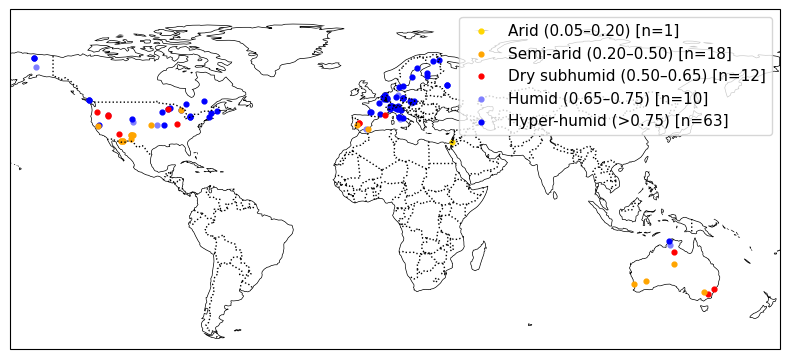

In [8]:
site_metrics_df['aridity_category'] = pd.cut(
    site_metrics_df['ai'],
    bins=[0.05, 0.20, 0.50, 0.65, 0.75, float('inf')],
    labels=['Arid', 'Semi-arid', 'Dry subhumid', 'Humid', 'Hyper-humid']
)

map_colors = {
    'Hyperarid': '#FFFF00',
    'Arid': '#FFD700',
    'Semi-arid': '#FFA500',
    'Dry subhumid': '#FF0000',
    'Humid': '#7F7FFF',
    'Hyper-humid': '#0000FF'
}

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-160, 180, -60, 90], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.BORDERS, edgecolor='black', linestyle=':')

for cat in ['Humid', 'Hyper-humid', 'Dry subhumid', 'Semi-arid', 'Arid']:
    subset = site_metrics_df[site_metrics_df['aridity_category'] == cat]
    plt.scatter(subset['lon'], subset['lat'], color=map_colors[cat],
                label=cat, s=12, transform=ccrs.PlateCarree())

order = ['Arid', 'Semi-arid', 'Dry subhumid', 'Humid', 'Hyper-humid']
handles, labels = ax.get_legend_handles_labels()
handle_dict = dict(zip(labels, handles))
ordered_handles = [handle_dict[cat] for cat in order]

counts = site_metrics_df['aridity_category'].value_counts().reindex(order)
order_labels = [
    f"Arid (0.05–0.20) [n={counts['Arid']}]",
    f"Semi-arid (0.20–0.50) [n={counts['Semi-arid']}]",
    f"Dry subhumid (0.50–0.65) [n={counts['Dry subhumid']}]",
    f"Humid (0.65–0.75) [n={counts['Humid']}]",
    f"Hyper-humid (>0.75) [n={counts['Hyper-humid']}]"
]

ax.legend(ordered_handles, order_labels, loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

# plt.savefig('figures/1_site_map.png')

## Table 2: Overall performance

In [9]:
df['doy'] = df['TIMESTAMP'].dt.dayofyear
df['year'] = df['TIMESTAMP'].dt.year

models = [
    'gpp_lstm_global', 'gpp_lstm_global_plus',
    'gpp_lstm_global_perm', 'gpp_lstm_global_perm_plus',
    'gpp_mlp_global', 'gpp_mlp_global_plus',
    'gpp_pmodel_global',

]

daily_r2, seasonal_r2, spatial_r2, daily_anom_r2, annual_anom_r2 = {}, {}, {}, {}, {}
daily_rmse, seasonal_rmse, spatial_rmse, daily_anom_rmse, annual_anom_rmse = {}, {}, {}, {}, {}

for model in models:
    daily_r2[model] = df['GPP_NT_VUT_REF'].corr(df[model]) ** 2
    daily_rmse[model] = np.sqrt(mean_squared_error(df['GPP_NT_VUT_REF'], df[model]))

    seasonal_df = df.groupby(['sitename', 'doy'], as_index=False)[['GPP_NT_VUT_REF', model]].mean()
    seasonal_r2[model] = seasonal_df['GPP_NT_VUT_REF'].corr(seasonal_df[model]) ** 2
    seasonal_rmse[model] = np.sqrt(mean_squared_error(seasonal_df['GPP_NT_VUT_REF'], seasonal_df[model]))

    spatial_df = df.groupby('sitename', as_index=False)[['GPP_NT_VUT_REF', model]].mean()
    spatial_r2[model] = spatial_df['GPP_NT_VUT_REF'].corr(spatial_df[model]) ** 2
    spatial_rmse[model] = np.sqrt(mean_squared_error(spatial_df['GPP_NT_VUT_REF'], spatial_df[model]))

    seasonal_cycle = df.groupby(['sitename', 'doy'], as_index=False)[['GPP_NT_VUT_REF', model]].mean()
    df_anom = pd.merge(df, seasonal_cycle, on=['sitename', 'doy'], suffixes=('', '_seasonal'))
    df_anom['obs_anom'] = df_anom['GPP_NT_VUT_REF'] - df_anom['GPP_NT_VUT_REF_seasonal']
    df_anom['pred_anom'] = df_anom[model] - df_anom[model + '_seasonal']
    daily_anom_r2[model] = df_anom['obs_anom'].corr(df_anom['pred_anom']) ** 2
    daily_anom_rmse[model] = np.sqrt(mean_squared_error(df_anom['obs_anom'], df_anom['pred_anom']))

    annual_df = df.groupby(['sitename', 'year'], as_index=False)[['GPP_NT_VUT_REF', model]].mean()
    multi_yr_mean = annual_df.groupby('sitename', as_index=False)['GPP_NT_VUT_REF'].mean().rename(columns={'GPP_NT_VUT_REF': 'obs_multi'})
    multi_yr_pred = annual_df.groupby('sitename', as_index=False)[model].mean().rename(columns={model: 'pred_multi'})
    annual_df = pd.merge(annual_df, multi_yr_mean, on='sitename')
    annual_df = pd.merge(annual_df, multi_yr_pred, on='sitename')
    annual_df['obs_anom'] = annual_df['GPP_NT_VUT_REF'] - annual_df['obs_multi']
    annual_df['pred_anom'] = annual_df[model] - annual_df['pred_multi']
    annual_anom_r2[model] = annual_df['obs_anom'].corr(annual_df['pred_anom']) ** 2
    annual_anom_rmse[model] = np.sqrt(mean_squared_error(annual_df['obs_anom'], annual_df['pred_anom']))

In [10]:
metrics = ['Daily', 'Seasonal', 'Spatial', 'Daily anom.', 'Annual anom.']
r2_results = pd.DataFrame({'Metric': metrics})
rmse_results = pd.DataFrame({'Metric': metrics})

def format_label(model):
    label = model.replace('gpp_', '').replace('_global', '')
    label = label.replace('plus', '+').replace('extra', '_extra').replace('perm', '_perm')
    label = label.replace('_', ' ').strip()
    return label

for model in models:
    label = format_label(model)
    r2_results[label] = [
        daily_r2[model],
        seasonal_r2[model],
        spatial_r2[model],
        daily_anom_r2[model],
        annual_anom_r2[model]
    ]
    rmse_results[label] = [
        daily_rmse[model],
        seasonal_rmse[model],
        spatial_rmse[model],
        daily_anom_rmse[model],
        annual_anom_rmse[model]
    ]

r2_results = r2_results.round(2)
rmse_results = rmse_results.round(2)

def highlight_best_and_second(df, higher_is_better=True):
    df_fmt = df.copy()
    model_cols = df.columns[1:]

    for i in range(len(df)):
        row = df.loc[i, model_cols]
        sorted_row = row.sort_values(ascending=not higher_is_better)
        best_val = sorted_row.iloc[0]
        second_val = sorted_row[sorted_row != best_val].iloc[0] if (sorted_row != best_val).any() else best_val

        for col in model_cols:
            val = df.loc[i, col]
            if val == best_val:
                df_fmt.loc[i, col] = f"\\textbf{{{val}}}"
            elif val == second_val:
                df_fmt.loc[i, col] = f"\\textbf{{\\textit{{{val}}}}}"

    return df_fmt

r2_results_fmt = highlight_best_and_second(r2_results, higher_is_better=True)

rmse_results_fmt = highlight_best_and_second(rmse_results, higher_is_better=False)

In [11]:
from IPython.display import display, HTML

def render_html_table(df):
    def format_cell(x):
        if isinstance(x, str):
            x = x.replace(r'\textbf{', '<b>').replace(r'\textit{', '<i>')
            x = x.replace(r'}', '</i>' if '<i>' in x and '</i>' not in x else '</b>')
        return x

    df_html = df.copy().applymap(format_cell)
    display(HTML(df_html.to_html(escape=False, index=False)))

render_html_table(r2_results_fmt)
render_html_table(rmse_results_fmt)

Metric,lstm,lstm +,lstm perm,lstm perm +,mlp,mlp +,pmodel
Daily,0.75,0.79,0.74,0.77,0.75,0.79,0.64
Seasonal,0.84,0.88,0.83,0.87,0.84,0.88,0.78
Spatial,0.73,0.81,0.73,0.77,0.73,0.82,0.61
Daily anom.,0.26,0.28,0.25,0.26,0.26,0.27,0.20
Annual anom.,0.10,0.1,0.14,0.1,0.12,0.12,0.05


Metric,lstm,lstm +,lstm perm,lstm perm +,mlp,mlp +,pmodel
Daily,1.92,1.79,1.96,1.85,1.92,1.77,2.32
Seasonal,1.37,1.2,1.4,1.26,1.39,1.17,1.65
Spatial,0.89,0.74,0.89,0.82,0.89,0.71,1.06
Daily anom.,1.37,1.35,1.39,1.39,1.37,1.37,1.64
Annual anom.,0.44,0.44,0.42,0.44,0.42,0.43,0.46


In [12]:
def highlight_best(df, higher_is_better=True):
    df_fmt = df.copy()
    cols = df.columns[1:]
    for i in range(len(df)):
        row = df.loc[i, cols]
        best = row.max() if higher_is_better else row.min()
        for c in cols:
            v = df.loc[i, c]
            if v == best:
                df_fmt.loc[i, c] = f"\\textbf{{{v}}}"
    return df_fmt

r2_fmt = highlight_best(r2_results, True)
rmse_fmt = highlight_best(rmse_results, False)

models_cols = r2_fmt.columns[1:].tolist()
model_names = ['LSTM', 'LSTM+', 'LSTM$_{perm}$', 'LSTM$_{perm}$+', 'MLP', 'MLP+', 'P-model']

def rows_from(df):
    rows = []
    for _, r in df.iterrows():
        metric = r["Metric"]
        vals = [str(r[c]) for c in models_cols]
        rows.append(f"{metric} & " + " & ".join(vals) + " \\\\")
    return rows

r2_rows = rows_from(r2_fmt)
rmse_rows = rows_from(rmse_fmt)

table = []
table.append("\\begin{table}[ht]")
table.append("\\centering")
table.append("\\small")
table.append("\\setlength{\\tabcolsep}{6pt}")
table.append("\\renewcommand{\\arraystretch}{1.15}")
table.append("\\begin{tabular}{l l " + "c" * len(models_cols) + "}")
table.append("\\hline")
table.append("Metric & Aggregation & " + " & ".join(model_names) + " \\\\")
table.append("\\hline")
table.append("\\$R^2$ & " + r2_rows[0])
for row in r2_rows[1:]:
    table.append(" & " + row)
table.append("\\hline")
table.append("\\RMSE & " + rmse_rows[0])
for row in rmse_rows[1:]:
    table.append(" & " + row)
table.append("\\hline")
table.append("\\end{tabular}")
table.append("\\caption{Model performance across metrics. Best values per row in bold.}")
table.append("\\label{tab:model_performance}")
table.append("\\end{table}")

latex_table = "\n".join(table)
print(latex_table)

\begin{table}[ht]
\centering
\small
\setlength{\tabcolsep}{6pt}
\renewcommand{\arraystretch}{1.15}
\begin{tabular}{l l ccccccc}
\hline
Metric & Aggregation & LSTM & LSTM+ & LSTM$_{perm}$ & LSTM$_{perm}$+ & MLP & MLP+ & P-model \\
\hline
\$R^2$ & Daily & 0.75 & \textbf{0.79} & 0.74 & 0.77 & 0.75 & \textbf{0.79} & 0.64 \\
 & Seasonal & 0.84 & \textbf{0.88} & 0.83 & 0.87 & 0.84 & \textbf{0.88} & 0.78 \\
 & Spatial & 0.73 & 0.81 & 0.73 & 0.77 & 0.73 & \textbf{0.82} & 0.61 \\
 & Daily anom. & 0.26 & \textbf{0.28} & 0.25 & 0.26 & 0.26 & 0.27 & 0.2 \\
 & Annual anom. & 0.1 & 0.1 & \textbf{0.14} & 0.1 & 0.12 & 0.12 & 0.05 \\
\hline
\RMSE & Daily & 1.92 & 1.79 & 1.96 & 1.85 & 1.92 & \textbf{1.77} & 2.32 \\
 & Seasonal & 1.37 & 1.2 & 1.4 & 1.26 & 1.39 & \textbf{1.17} & 1.65 \\
 & Spatial & 0.89 & 0.74 & 0.89 & 0.82 & 0.89 & \textbf{0.71} & 1.06 \\
 & Daily anom. & 1.37 & \textbf{1.35} & 1.39 & 1.39 & 1.37 & 1.37 & 1.64 \\
 & Annual anom. & 0.44 & 0.44 & \textbf{0.42} & 0.44 & \textbf{0.42} & 0.4

## Figure 2: Overall performance

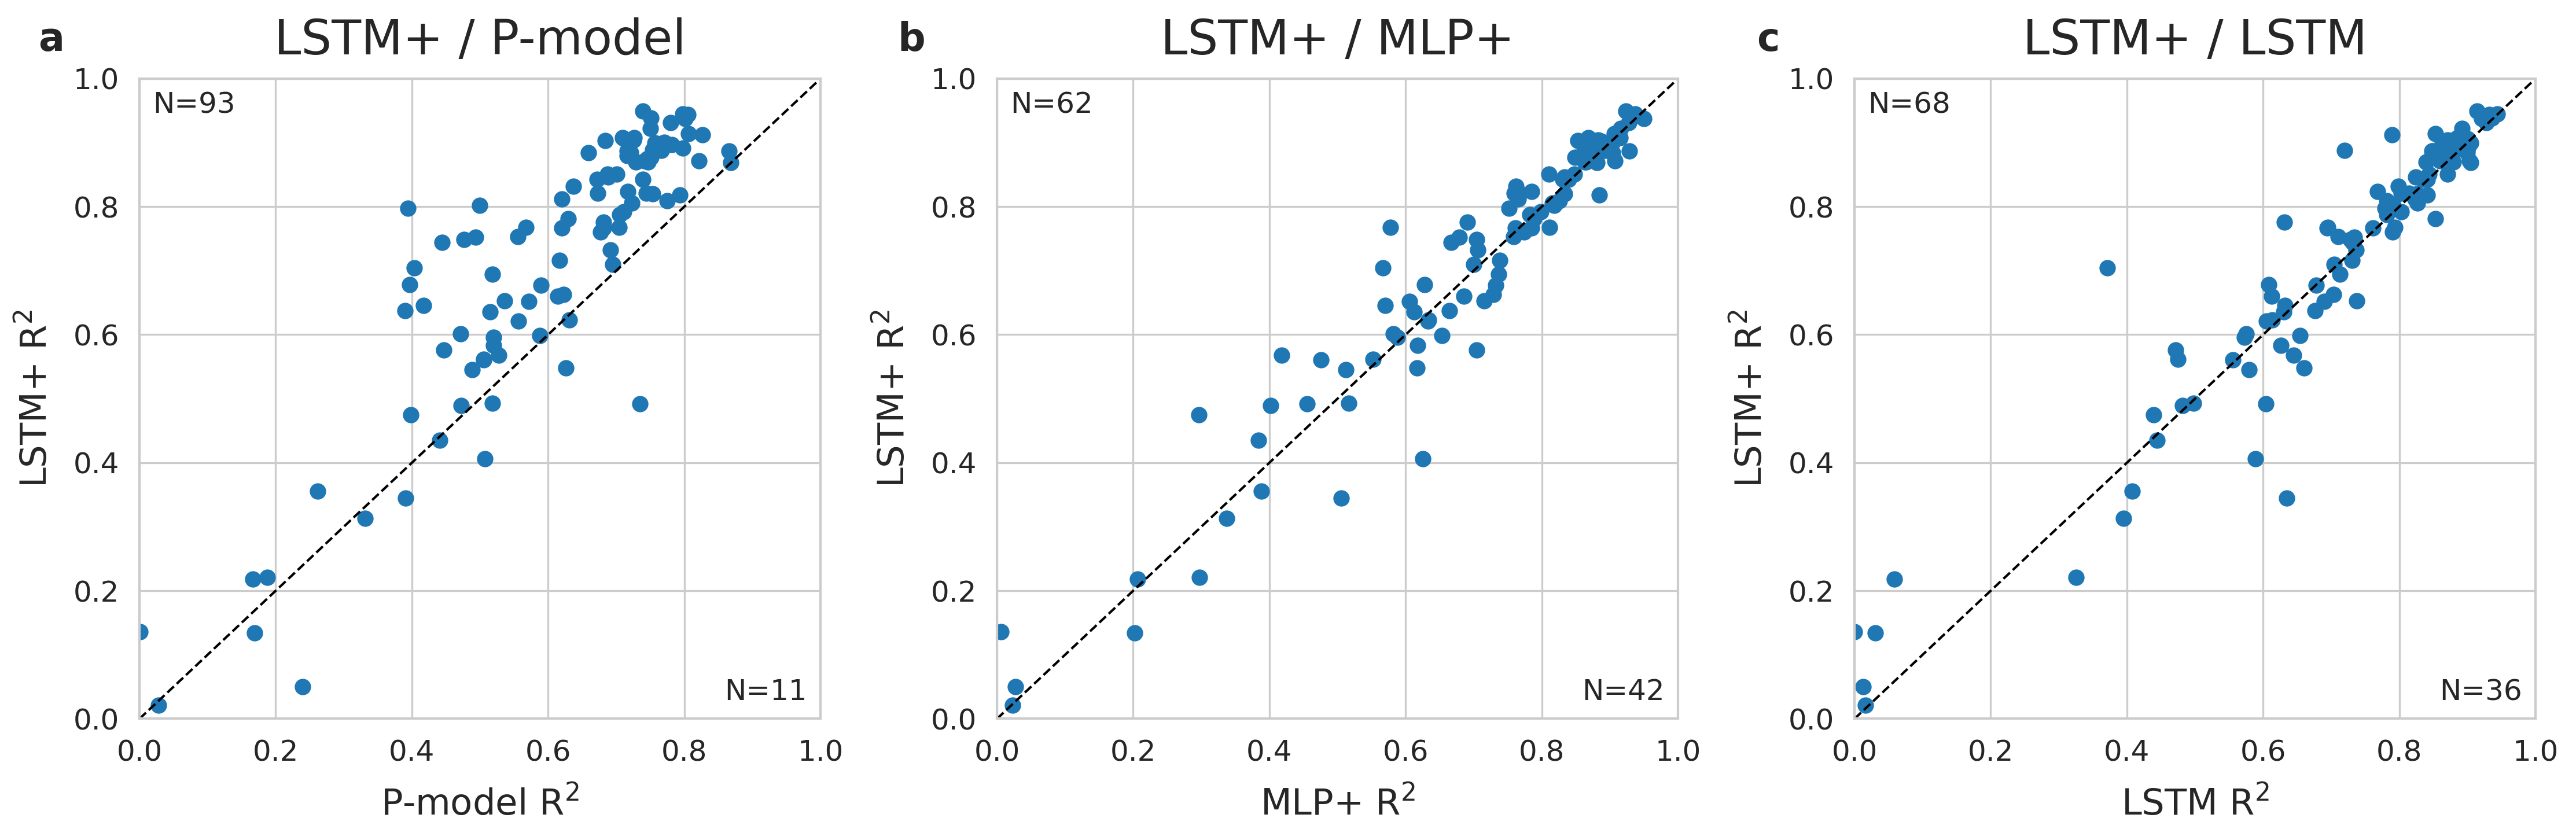

In [13]:
import matplotlib.pyplot as plt

set_publication_style()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# LSTM / P-model
x = site_metrics_df['pmodel_global_r2']
y = site_metrics_df['lstm_global_plus_r2']
axes[0].scatter(x, y)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel(r'P-model R$^2$')
axes[0].set_ylabel(r'LSTM+ R$^2$')
axes[0].set_title('LSTM+ / P-model')
n_y_better = (y > x).sum()
n_x_better = (x > y).sum()
axes[0].text(0.02, 0.98, f'N={n_y_better}', transform=axes[0].transAxes, ha='left', va='top')
axes[0].text(0.98, 0.02, f'N={n_x_better}', transform=axes[0].transAxes, ha='right', va='bottom')

# LSTM+ / MLP+
x = site_metrics_df['mlp_global_plus_r2']
y = site_metrics_df['lstm_global_plus_r2']
axes[1].scatter(x, y)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel(r'MLP+ R$^2$')
axes[1].set_ylabel(r'LSTM+ R$^2$')
axes[1].set_title('LSTM+ / MLP+')
n_y_better = (y > x).sum()
n_x_better = (x > y).sum()
axes[1].text(0.02, 0.98, f'N={n_y_better}', transform=axes[1].transAxes, ha='left', va='top')
axes[1].text(0.98, 0.02, f'N={n_x_better}', transform=axes[1].transAxes, ha='right', va='bottom')

# LSTM+ / LSTM
x = site_metrics_df['lstm_global_r2']
y = site_metrics_df['lstm_global_plus_r2']
axes[2].scatter(x, y)
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].set_xlabel(r'LSTM R$^2$')
axes[2].set_ylabel(r'LSTM+ R$^2$')
axes[2].set_title('LSTM+ / LSTM')
n_y_better = (y > x).sum()
n_x_better = (x > y).sum()
axes[2].text(0.02, 0.98, f'N={n_y_better}', transform=axes[2].transAxes, ha='left', va='top')
axes[2].text(0.98, 0.02, f'N={n_x_better}', transform=axes[2].transAxes, ha='right', va='bottom')

fig.text(0.02, 0.96, 'a', fontweight='heavy', fontfamily='sans-serif', ha='left', va='top', fontsize=16)
fig.text(0.35, 0.96, 'b', fontweight='heavy', fontfamily='sans-serif', ha='left', va='top', fontsize=16)
fig.text(0.68, 0.96, 'c', fontweight='heavy', fontfamily='sans-serif', ha='left', va='top', fontsize=16)

plt.tight_layout()

# plt.savefig('figures/2_all.png')

plt.show()

## Figure 3: Seasonal cycles

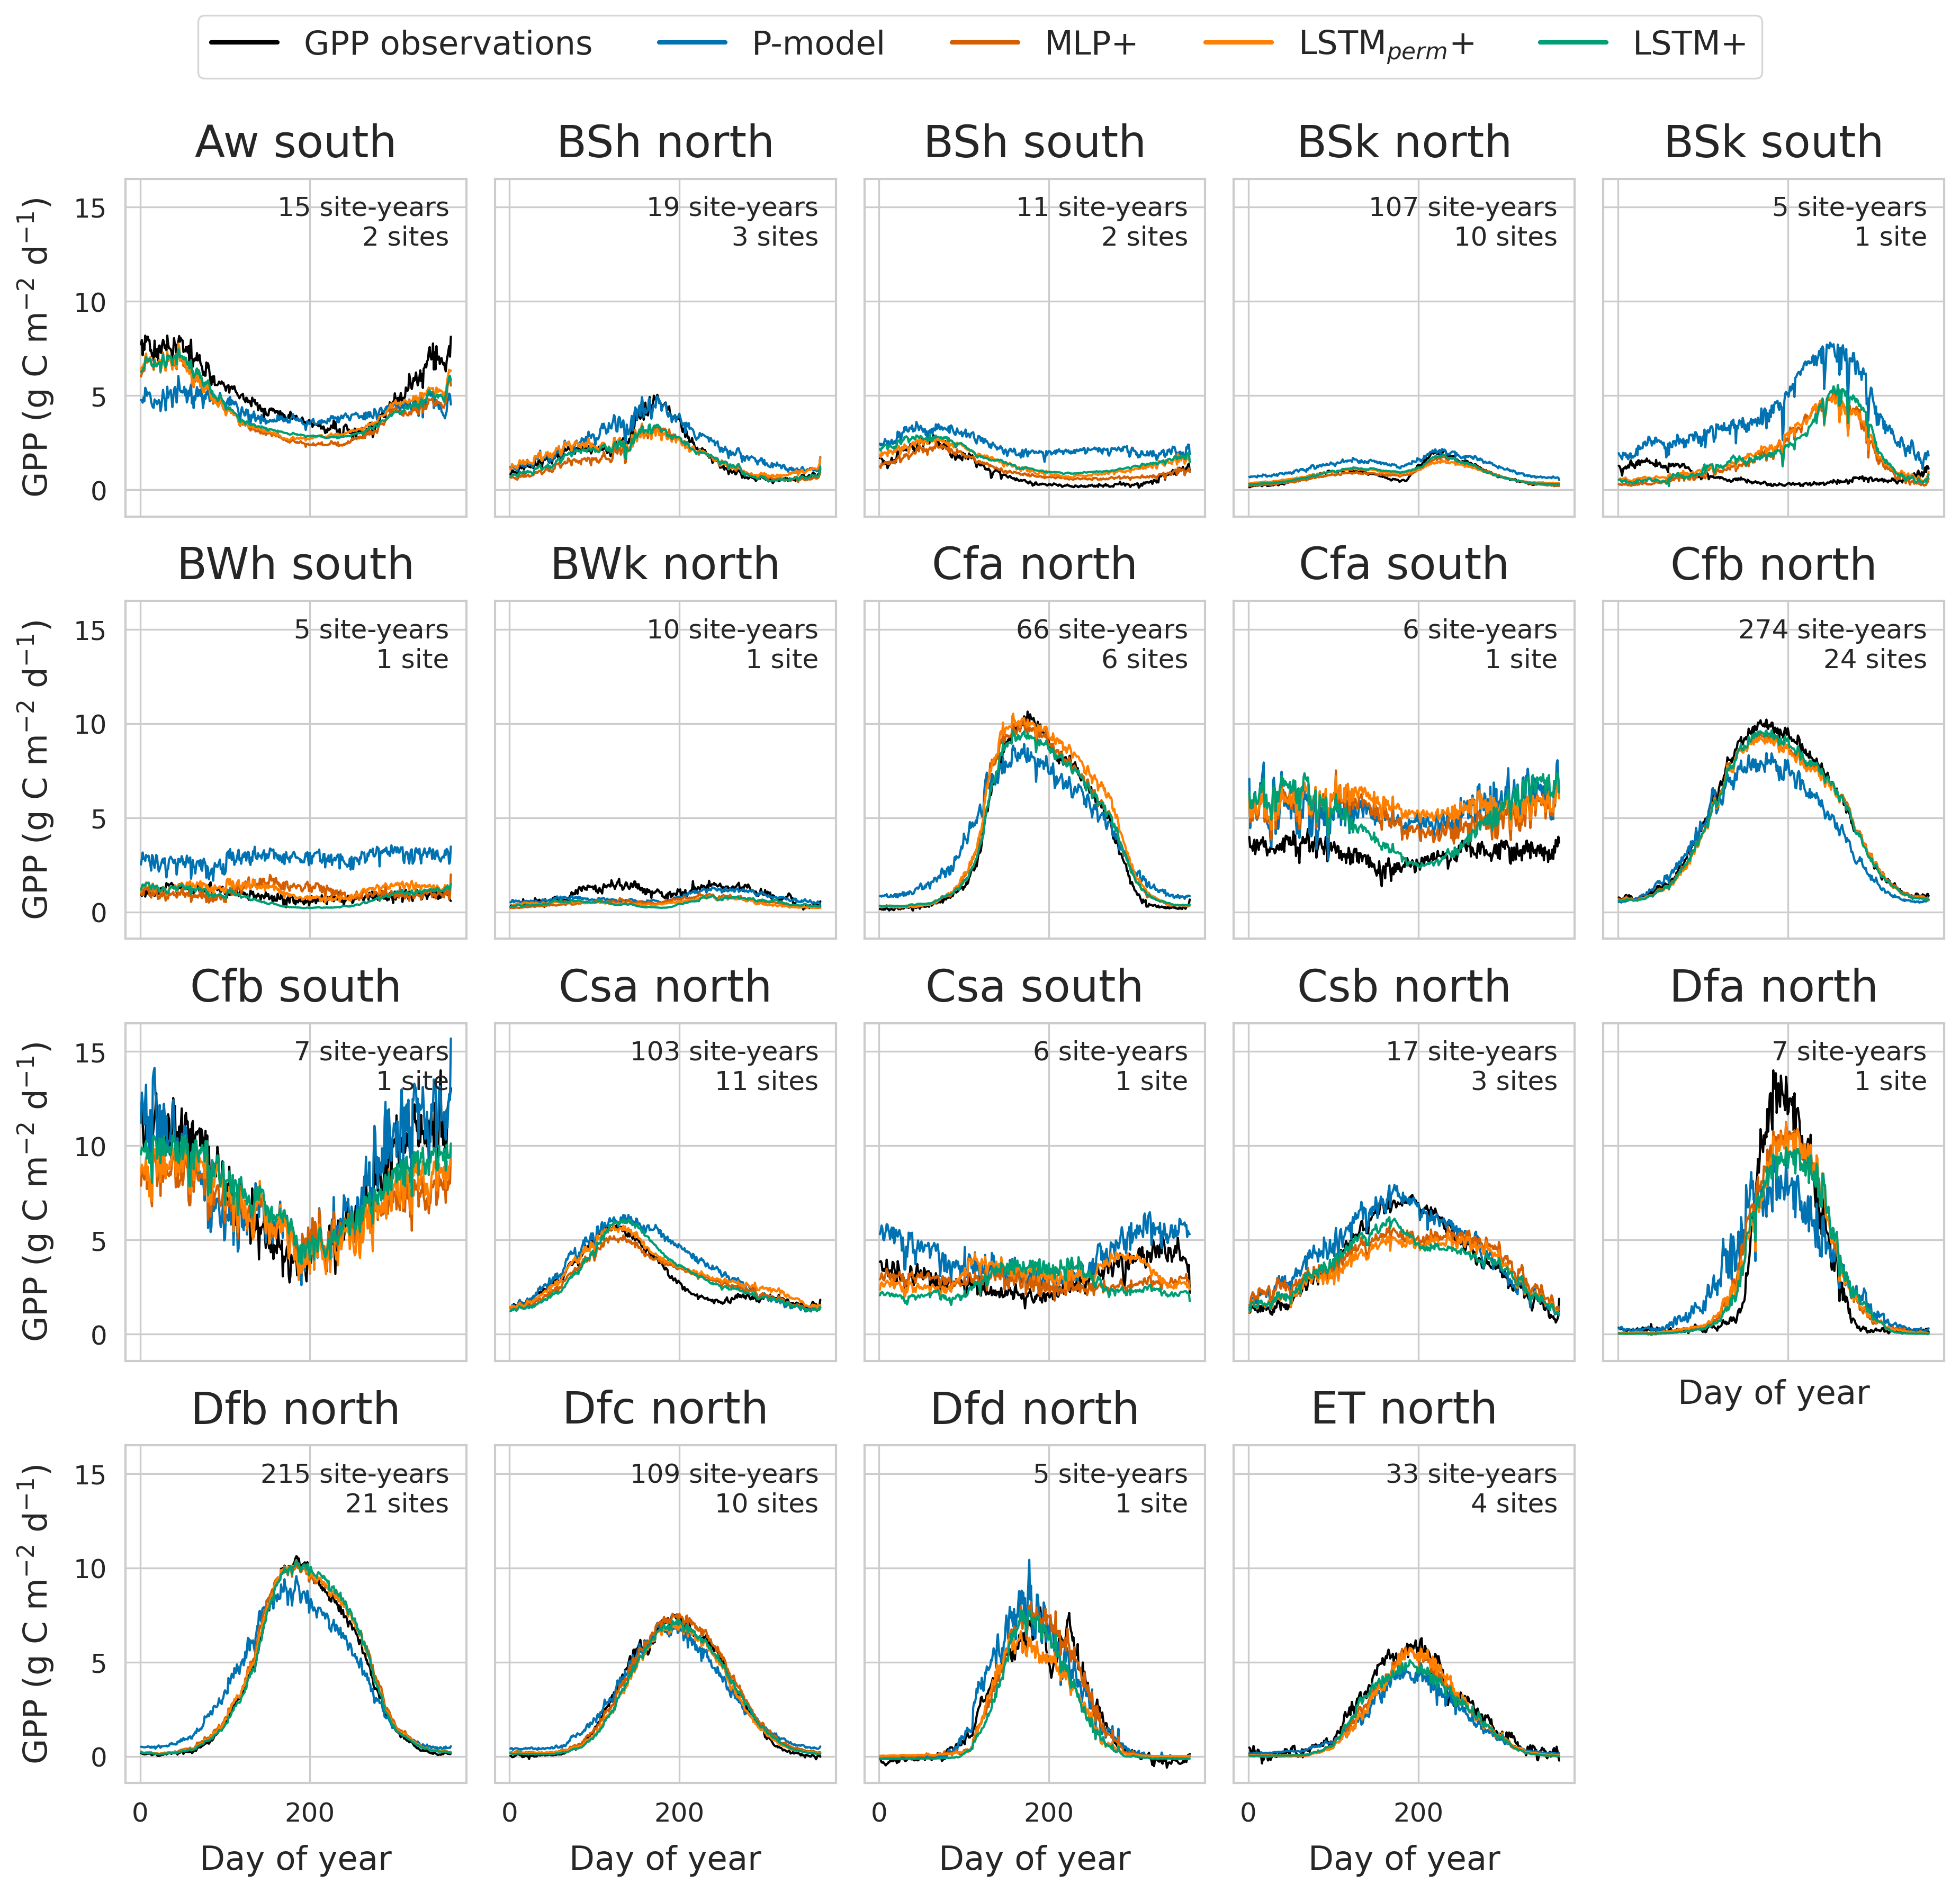

In [14]:
set_publication_style()

model_cols = ['gpp_pmodel_global', 'gpp_mlp_global_plus', 'gpp_lstm_global_perm_plus', 'gpp_lstm_global_plus']

seasonal = df.groupby(['koeppen_hemisphere', 'doy'])[
    ['GPP_NT_VUT_REF'] + model_cols
].mean().reset_index()

site_counts = df.groupby('koeppen_hemisphere')['sitename'].nunique()
koeppen_values = sorted(site_counts.index.tolist())
ncols = 5
nrows = (len(koeppen_values) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 3 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i, koeppen in enumerate(koeppen_values):
    sub = seasonal[seasonal['koeppen_hemisphere'] == koeppen].sort_values('doy')
    ax = axes[i]
    ax.plot(sub['doy'], sub['GPP_NT_VUT_REF'], label='GPP observations', color='black', lw=1)

    for model_col in model_cols:
        label = model_label_map[model_col]
        linestyle = '-'
        ax.plot(sub['doy'], sub[model_col], label=label, color=colors[label], lw=1, ls=linestyle)

    ax.set_title(koeppen)
    if i % ncols == 0:
        ax.set_ylabel('GPP (g C m$^{-2}$ d$^{-1}$)')

    site_years = df[df['koeppen_hemisphere'] == koeppen][['sitename', 'year']].drop_duplicates().shape[0]
    site_count = df[df['koeppen_hemisphere'] == koeppen]['sitename'].nunique()
    site_label = '1 site' if site_count == 1 else f'{site_count} sites'
    ax.text(0.95, 0.95, f'{site_years} site-years\n{site_label}', transform=ax.transAxes, ha='right', va='top')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

n_plots = len(koeppen_values)
label_indices = []
for col in range(ncols):
    bottom_index = (nrows - 1) * ncols + col
    if bottom_index < n_plots:
        label_indices.append(bottom_index)
    elif nrows >= 2:
        second_last_index = (nrows - 2) * ncols + col
        if second_last_index < n_plots:
            label_indices.append(second_last_index)

for idx in range(n_plots):
    axes[idx].set_xlabel('Day of year' if idx in label_indices else '')

legend_labels = ['GPP observations'] + list(model_cols)
legend_values = ['GPP observations'] + [model_label_map[col] for col in model_cols]
lines = [
    plt.Line2D([], [], color='black', lw=2, label='GPP observations')
] + [
    plt.Line2D([], [], color=colors[label], lw=2, label=label, ls='-')
    for label in legend_values[1:]
]

fig.legend(handles=lines, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=5)
fig.tight_layout(rect=[0, 0, 1, 0.95])

# plt.savefig('figures/3_seasonalcycle.png', bbox_inches='tight')

plt.show()


## Figure 4: PCWD

/tmp/ipykernel_1998601/812321373.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.98, 1])  # leave space for legend


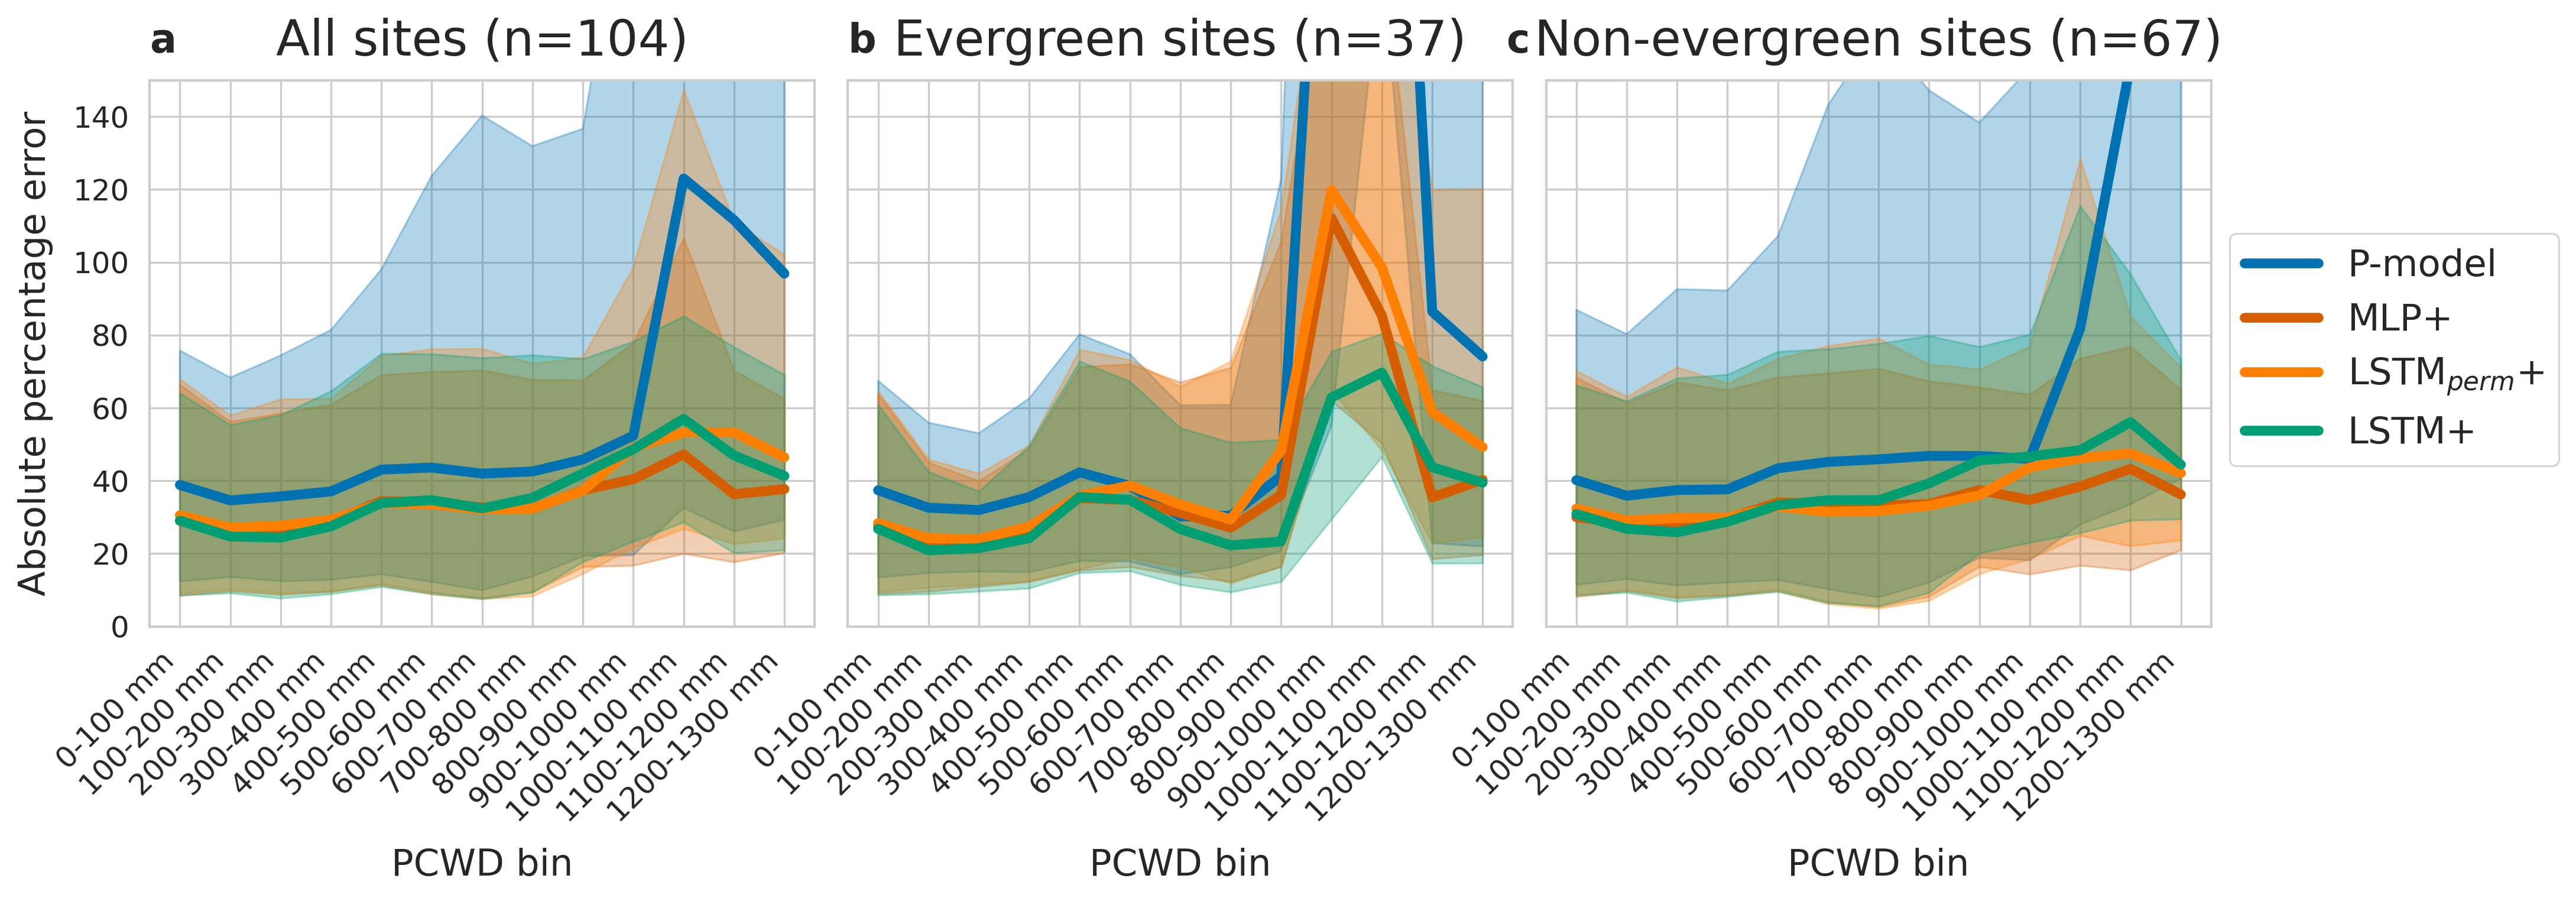

In [15]:
set_publication_style(figsize=(15, 4))
fig = plt.figure(figsize=(15, 4))

gs = fig.add_gridspec(1, 3, wspace=0.05)
ax_all = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

ax1.tick_params(labelleft=False)
ax2.tick_params(labelleft=False)

df_subset = df.copy()
df_subset = df_subset[df_subset['pcwd'] <= 1300]
bins = np.arange(0, 1301, 100)

# Add MAPE columns for all models
mape_models = {
    'pmodel_global': 'P-model',
    'mlp_global_plus': 'MLP+',
    'lstm_global_perm_plus': 'LSTM$_{perm}$+',
    'lstm_global_plus': 'LSTM+',
    # 'tcn_global_extra_plus': 'TCN_extra+',
}

for col, label in mape_models.items():
    df_subset[f'{col}_mape'] = np.abs(df_subset['GPP_NT_VUT_REF'] - df_subset[f'gpp_{col}']) / df_subset['GPP_NT_VUT_REF'] * 100

df_subset['pcwd_bin'] = pd.cut(df_subset['pcwd'], bins=bins, right=False, include_lowest=True)

def compute_summary_stats(d):
    melt_vars = [f'{k}_mape' for k in mape_models.keys()]
    d_long = d.melt(id_vars=['pcwd_bin'], value_vars=melt_vars, var_name='Model', value_name='Global MAPE')
    d_long['Model'] = d_long['Model'].str.replace('_mape', '')
    d_long['Model'] = d_long['Model'].map(mape_models)
    s = d_long.groupby(['pcwd_bin', 'Model'])['Global MAPE'].agg(
        median='median',
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    ).reset_index()
    s['pcwd_bin_mid'] = s['pcwd_bin'].apply(lambda x: x.right)
    return s

def filter_and_summarize(d):
    c = d['pcwd_bin'].value_counts()
    v = c[c >= 100].index
    d = d[d['pcwd_bin'].isin(v)]
    s = compute_summary_stats(d)
    s['count'] = s['pcwd_bin'].map(c)
    s['pcwd_bin'] = s['pcwd_bin'].cat.remove_unused_categories()
    return s

df_evergreen = df_subset[df_subset['is_evergreen']]
df_non_evergreen = df_subset[~df_subset['is_evergreen']]

s_evergreen = filter_and_summarize(df_evergreen)
s_non_evergreen = filter_and_summarize(df_non_evergreen)
s_all = filter_and_summarize(df_subset)

def plot_summary(a, d, t):
    d = d.sort_values('pcwd_bin_mid')
    unique_bins = d.drop_duplicates('pcwd_bin').sort_values('pcwd_bin_mid')
    x_positions = unique_bins['pcwd_bin'].apply(lambda x: x.right)
    bin_labels = [f"{int(row['pcwd_bin'].left)}-{int(row['pcwd_bin'].right)} mm" for _, row in unique_bins.iterrows()]
    
    for m in mape_models.values():
        subset = d[d['Model'] == m]
        x = subset['pcwd_bin_mid']
        y = subset['median']
        y1 = subset['q1']
        y3 = subset['q3']
        a.plot(x, y, label=m, color=colors.get(m))
        a.fill_between(x, y1, y3, alpha=0.3, color=colors.get(m))
    
    a.set_title(t)
    a.set_xticks(x_positions)
    a.set_xticklabels(bin_labels, rotation=45, ha='right')
    a.set_ylim(0, 150)

plot_summary(ax_all, s_all, f'All sites (n={df_subset["sitename"].nunique()})')
ax_all.set_xlabel('PCWD bin')
ax_all.set_ylabel('Absolute percentage error')

plot_summary(ax1, s_evergreen, f'Evergreen sites (n={df_evergreen["sitename"].nunique()})')
plot_summary(ax2, s_non_evergreen, f'Non-evergreen sites (n={df_non_evergreen["sitename"].nunique()})')

ax1.set_xlabel('PCWD bin')
ax2.set_xlabel('PCWD bin')

ax_all.text(0, 1.05, 'a', transform=ax_all.transAxes, fontsize=16, fontweight='heavy', fontfamily='sans-serif')
ax1.text(0, 1.05, 'b', transform=ax1.transAxes, fontsize=16, fontweight='heavy', fontfamily='sans-serif')
ax2.text(-0.06, 1.05, 'c', transform=ax2.transAxes, fontsize=16, fontweight='heavy', fontfamily='sans-serif')

# Legend outside plot
handles, labels = ax_all.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.9, 0.5))
fig.tight_layout(rect=[0, 0, 0.98, 1])  # leave space for legend

# plt.savefig('figures/4_pcwd.png', bbox_inches='tight')

plt.show()


## Figure 5: cold acclimation

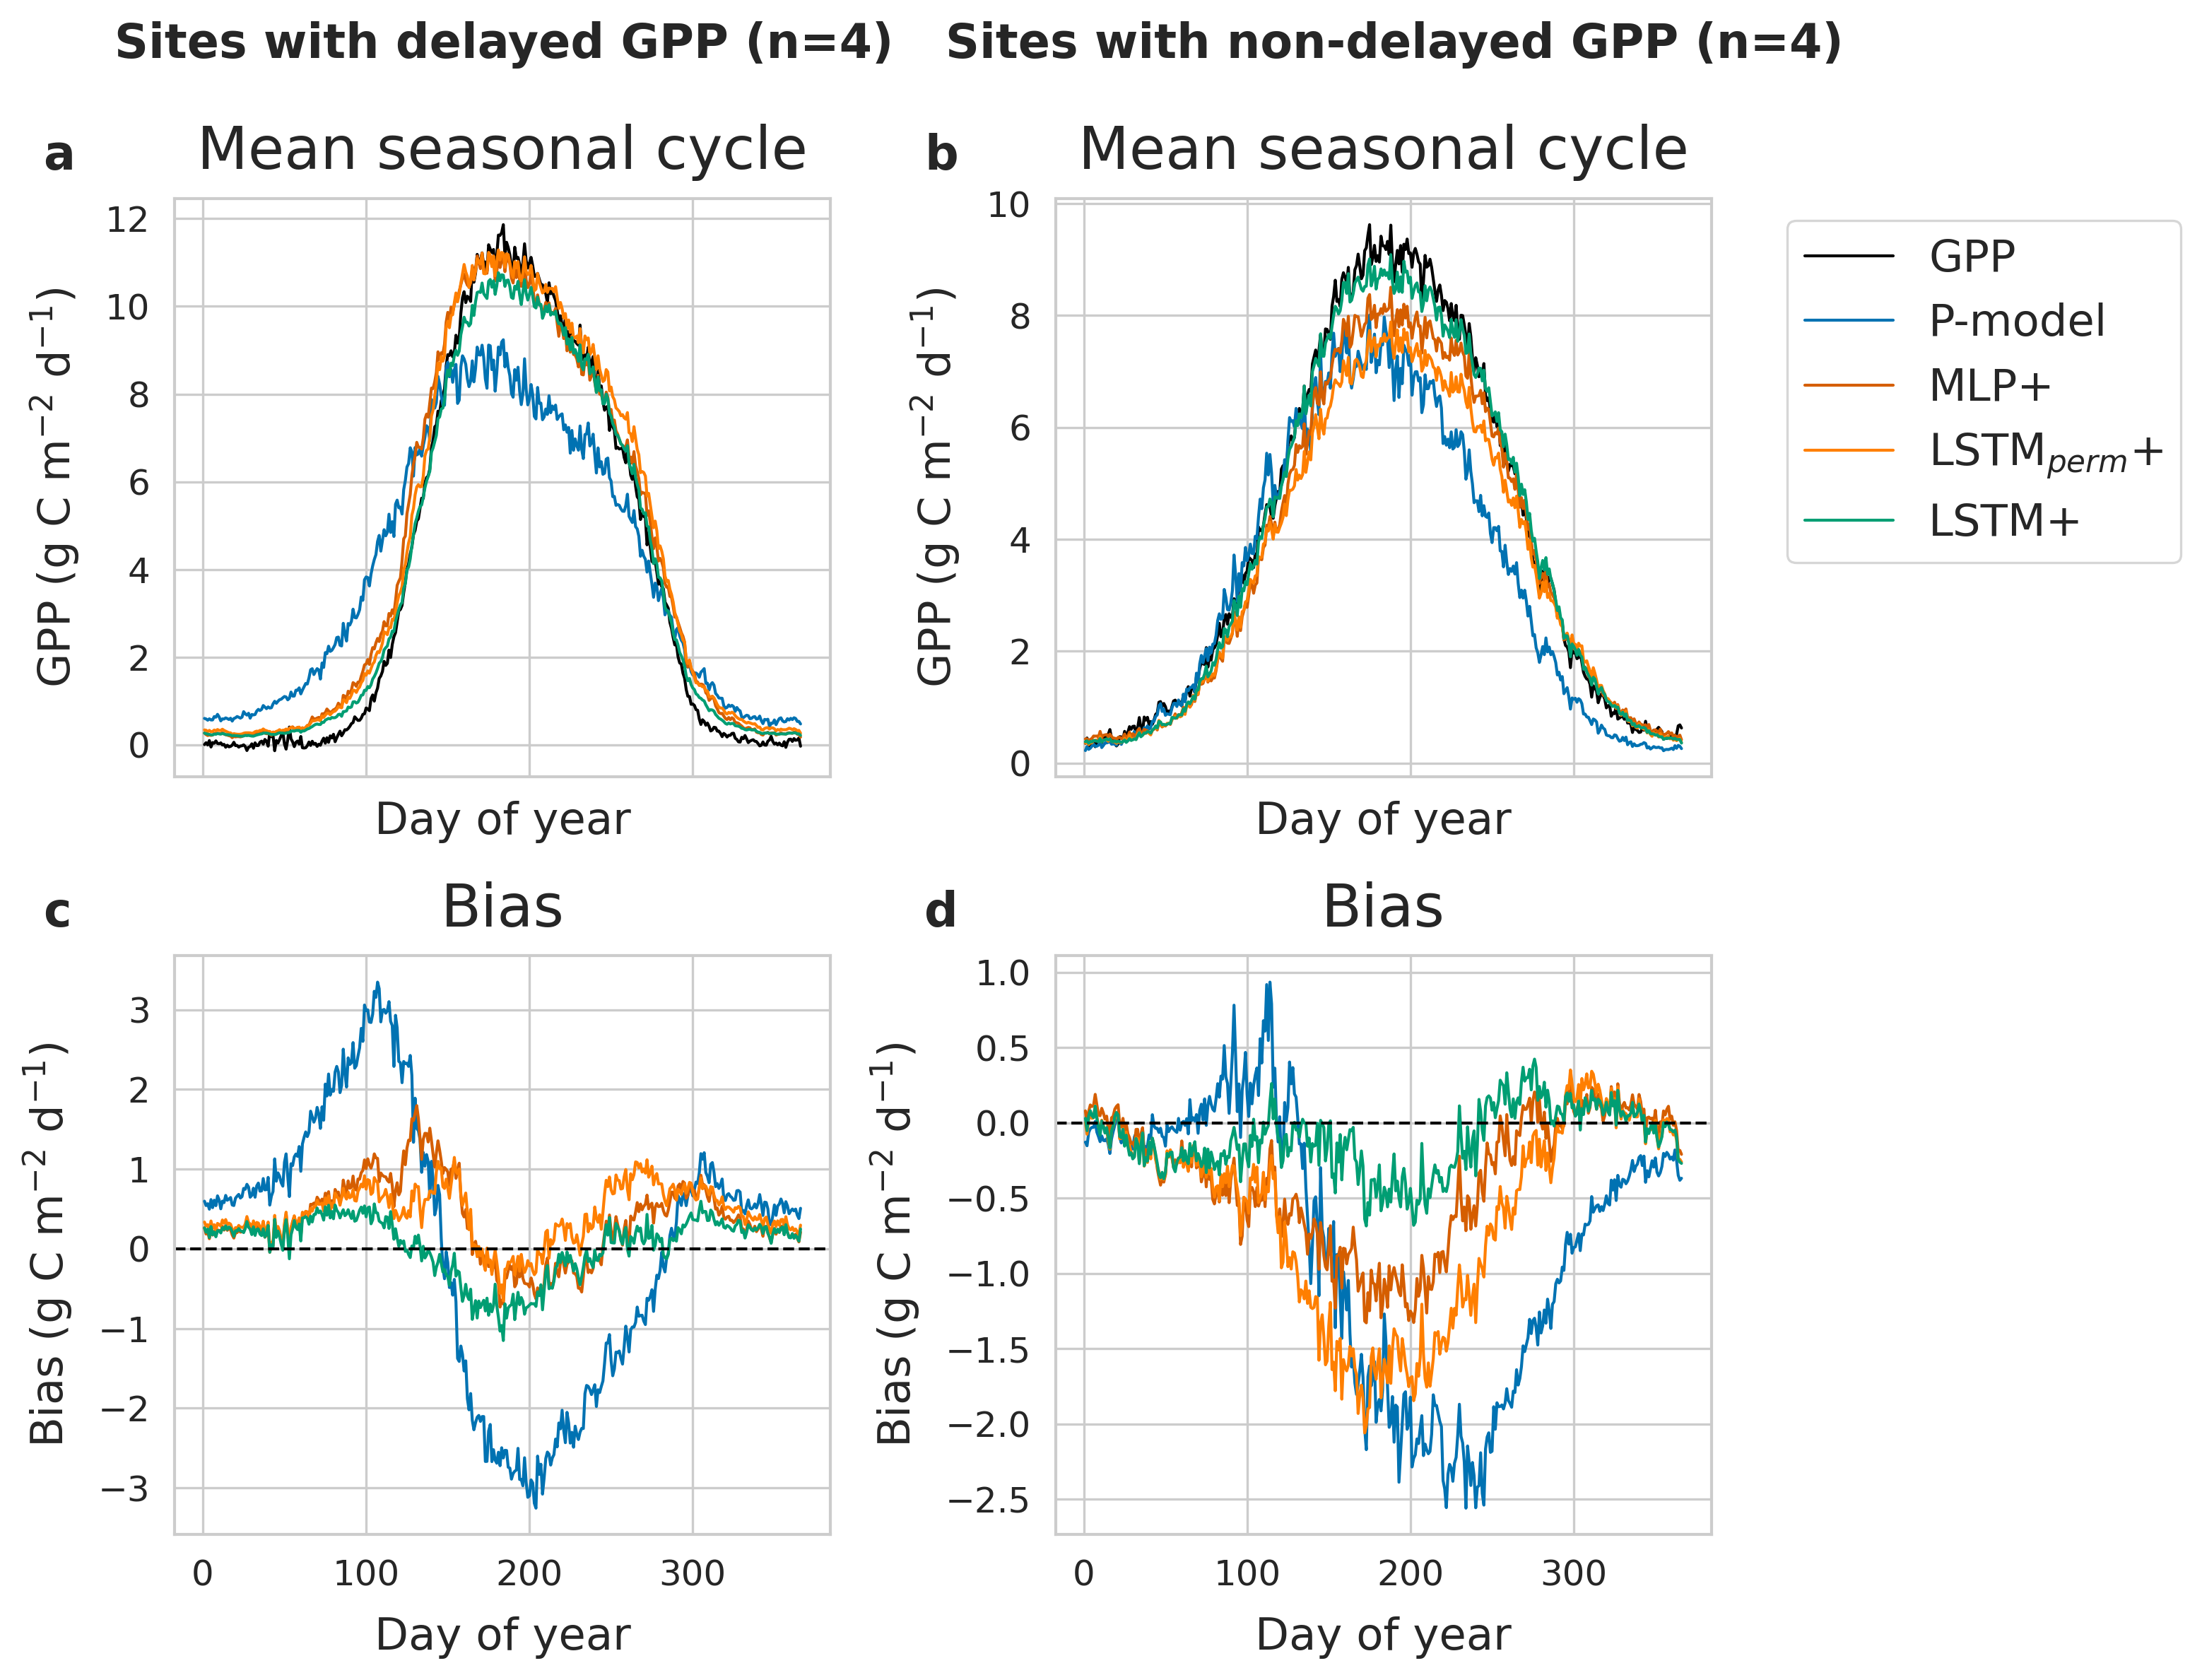

In [16]:
set_publication_style(figsize=(12, 8))

alpha_shade = 0.15

df_delayed = df[df['cold_acclimation_type'] == 'cold_delayedgpp']
df_non_delayed = df[df['cold_acclimation_type'] == 'cold_nodelayedgpp']

model_cols = ['gpp_pmodel_global', 'gpp_mlp_global_plus', 'gpp_lstm_global_perm_plus', 'gpp_lstm_global_plus']

delayed_cycle = df_delayed.groupby('doy')[['GPP_NT_VUT_REF'] + model_cols].mean().reset_index().sort_values('doy')
non_delayed_cycle = df_non_delayed.groupby('doy')[['GPP_NT_VUT_REF'] + model_cols].mean().reset_index().sort_values('doy')

delayed_quantiles = {}
non_delayed_quantiles = {}
for col in ['GPP_NT_VUT_REF'] + model_cols:
    delayed_quantiles[col] = {
        'q25': df_delayed.groupby('doy')[col].quantile(0.25).reset_index().sort_values('doy'),
        'q75': df_delayed.groupby('doy')[col].quantile(0.75).reset_index().sort_values('doy')
    }
    non_delayed_quantiles[col] = {
        'q25': df_non_delayed.groupby('doy')[col].quantile(0.25).reset_index().sort_values('doy'),
        'q75': df_non_delayed.groupby('doy')[col].quantile(0.75).reset_index().sort_values('doy')
    }

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True)

def plot_predictions(ax, cycle, quantiles, title):
    ax.plot(cycle['doy'], cycle['GPP_NT_VUT_REF'], label='GPP', color='black', linestyle='-', linewidth=1)
    for model_col in model_cols:
        label = model_label_map[model_col]
        ax.plot(cycle['doy'], cycle[model_col], label=label, color=colors[label], linewidth=1)
    ax.set_title(title)
    ax.set_ylabel('GPP (g C m$^{-2}$ d$^{-1}$)')
    ax.set_xlabel('Day of year')
    ax.grid(True)

plot_predictions(axes[0, 0], delayed_cycle, delayed_quantiles, 'Mean seasonal cycle')
plot_predictions(axes[0, 1], non_delayed_cycle, non_delayed_quantiles, 'Mean seasonal cycle')

axes[0, 1].legend(loc='upper right', bbox_to_anchor=(1.75, 1))

def compute_daily_bias(df_subset):
    bias = {}
    for model_col in model_cols:
        label = model_label_map[model_col]
        bias[label] = (
            df_subset.groupby('doy')
            .apply(lambda x: (x[model_col] - x['GPP_NT_VUT_REF']).mean())
            .reset_index(name=label)
            .sort_values('doy')
        )
    return bias

bias_delayed = compute_daily_bias(df_delayed)
bias_non_delayed = compute_daily_bias(df_non_delayed)

def plot_bias(ax, bias_dict, title):
    for label, df_bias in bias_dict.items():
        ax.plot(df_bias['doy'], df_bias[label], label=label, color=colors[label], linewidth=1)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_ylabel('Bias (g C m$^{-2}$ d$^{-1}$)')
    ax.set_xlabel('Day of year')
    ax.grid(True)

plot_bias(axes[1, 0], bias_delayed, 'Bias') 
plot_bias(axes[1, 1], bias_non_delayed, 'Bias')

axes[0, 0].text(-0.2, 1.05, 'a', transform=axes[0, 0].transAxes, fontsize=16, fontweight='heavy', fontfamily='sans-serif')
axes[0, 1].text(-0.2, 1.05, 'b', transform=axes[0, 1].transAxes, fontsize=16, fontweight='heavy', fontfamily='sans-serif')
axes[1, 0].text(-0.2, 1.05, 'c', transform=axes[1, 0].transAxes, fontsize=16, fontweight='heavy', fontfamily='sans-serif')
axes[1, 1].text(-0.2, 1.05, 'd', transform=axes[1, 1].transAxes, fontsize=16, fontweight='heavy', fontfamily='sans-serif')

fig.text(0.215, 0.96, "Sites with delayed GPP (n=4)", ha="center", va="bottom", fontsize=16, fontweight="bold")
fig.text(0.565, 0.96, "Sites with non-delayed GPP (n=4)", ha="center", va="bottom", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 0.96, 0.95])

# plt.savefig('figures/5_delayedgpp.png', bbox_inches='tight')

plt.show()


## Figure 6: Event analysis

In [17]:
df_flue = pd.read_csv('data/flue_stocker18nphyt.csv', parse_dates=['date']).rename(columns={'date': 'TIMESTAMP', 'site': 'sitename'})
df_flue = df_flue.merge(df[['sitename', "TIMESTAMP", "GPP_NT_VUT_REF", "gpp_lstm_global", "gpp_mlp_global", "gpp_pmodel_global", "gpp_lstm_global_perm"]],
                        on=['sitename', 'TIMESTAMP'], how='left')

In [18]:
data_path = "/cluster/work/igp_psr/sbiege/data/FLUXDATAKIT_FLUXNET_v342"
csv_files = glob.glob(os.path.join(data_path, "*_DD_*.csv"))
dataframes = []
for file in csv_files:
    sitename = os.path.basename(file)[4:10]
    df_tmp = pd.read_csv(file, parse_dates=['TIMESTAMP'])
    df_tmp["sitename"] = sitename
    dataframes.append(df_tmp)
df_all = pd.concat(dataframes, ignore_index=True)

df_with_tmin = df.merge(
    df_all[['sitename', 'TIMESTAMP', 'TMIN_F_MDS']],
    on=['sitename', 'TIMESTAMP'],
    how='left'
).rename(columns={'TMIN_F_MDS': 'tmin'})

In [19]:
def _get_consecutive_flags(flags, leng_threshold):
    v = flags.fillna(False).astype(bool).to_numpy()
    starts, lens, run = [], [], 0
    for i, x in enumerate(v):
        if x:
            run += 1
        else:
            if run >= leng_threshold:
                starts.append(i - run); lens.append(run)
            run = 0
    if run >= leng_threshold:
        starts.append(len(v) - run); lens.append(run)
    return list(zip(starts, lens))  # list of (start, length)

In [20]:
def _merge_short_gaps_bool(v, max_gap):
    if max_gap <= 0:
        return v
    x = v.astype(int)
    i = 0
    n = len(x)
    while i < n:
        while i < n and x[i] == 1:
            i += 1
        g0 = i
        while i < n and x[i] == 0:
            i += 1
        gl = i - g0
        if gl > 0:
            left = g0 - 1 >= 0 and x[g0 - 1] == 1
            right = i < n and x[i] == 1
            if left and right and gl <= max_gap:
                x[g0:i] = 1
    return x.astype(bool)

In [21]:
def align_events(
    df,
    df_isevent,
    dovars,
    leng_threshold,
    before,
    after,
    do_norm=True,
    nbins=6,
    normbin=2,
    site_col="sitename",
    date_col="TIMESTAMP",
    event_col="isevent",
    cap_to_event=False,
    require_full_window=True
):
    dfm = df.merge(
        df_isevent[[site_col, date_col, event_col]].rename(columns={event_col: "isevent"}),
        on=[site_col, date_col],
        how="left"
    ).sort_values([site_col, date_col]).reset_index(drop=True)
    dfm["isevent"] = dfm["isevent"].fillna(False).astype(bool)
    out, inst = [], 0
    for site, g in dfm.groupby(site_col, sort=False):
        g = g.reset_index(drop=True)
        for s, L in _get_consecutive_flags(g["isevent"], leng_threshold):
            aft = min(after, L) if cap_to_event else after
            dday = np.arange(-before, aft + 1)
            idxs = s + dday
            if require_full_window:
                if idxs.min() < 0 or idxs.max() >= len(g):
                    continue
                add = g.iloc[idxs].copy()
            else:
                mask = (idxs >= 0) & (idxs < len(g))
                if not mask.any():
                    continue
                add = g.iloc[idxs[mask]].copy()
                dday = dday[mask]
            if len(add) != len(dday):
                continue
            inst += 1
            add["dday"] = dday
            add["inst"] = inst
            out.append(add)
    if not out:
        return {"df_dday": None, "df_dday_aggbydday": None}
    df_dday = pd.concat(out, ignore_index=True)
    if do_norm:
        if do_norm:
            norm_window = (-10, -1)
            for c in dovars:
                df_dday[c] = df_dday.groupby("inst")[c].transform(
                    lambda x: x - x[df_dday.loc[x.index, "dday"].between(*norm_window)].median()
                )
    aggs = {}
    for c in dovars:
        aggs[f"{c}_median"] = (c, "median")
        aggs[f"{c}_q33"] = (c, lambda x: x.quantile(0.33))
        aggs[f"{c}_q66"] = (c, lambda x: x.quantile(0.66))
    df_dday_aggbydday = df_dday.groupby("dday", as_index=False).agg(**aggs).sort_values("dday")
    return {"df_dday": df_dday, "df_dday_aggbydday": df_dday_aggbydday}

In [22]:
def eval_eventresponse(
    df,
    df_events,
    before,
    after,
    leng_threshold,
    nbins,
    do_norm=True,
    mod=None,
    obs=None,
    site_col="sitename",
    date_col="TIMESTAMP",
    event_col="isevent",
    cap_to_event=False,
    require_full_window=True,
    norm_window=(-10, -1)
):
    d = df.copy()
    d["bias"] = d[mod] - d[obs]

    out = align_events(
        d,
        df_events,
        ["bias"],
        leng_threshold,
        before,
        after,
        do_norm=False,
        nbins=nbins,
        site_col=site_col,
        date_col=date_col,
        event_col=event_col,
        cap_to_event=cap_to_event,
        require_full_window=require_full_window,
    )

    df_dday = out["df_dday"]
    if df_dday is None or len(df_dday) == 0:
        return None

    def normalize_event(g):
        ref = g.loc[g["dday"].between(*norm_window), "bias"]
        if len(ref.dropna()) == 0:
            return g.iloc[0:0]  # ✅ return empty DataFrame with same columns
        g["bias"] = g["bias"] - ref.median()
        return g

    df_dday = df_dday.groupby("inst", group_keys=False).apply(normalize_event)

    if df_dday is None or len(df_dday) == 0:
        return None

    df_dday_aggbydday = df_dday.groupby("dday", as_index=False).agg(
        bias_median=("bias", "median"),
        bias_q33=("bias", lambda x: x.quantile(0.33)),
        bias_q66=("bias", lambda x: x.quantile(0.66)),
    ).sort_values("dday")

    return df_dday_aggbydday

In [23]:
def build_drought_flags_from_flue(
    df_flue,
    site_col="sitename",
    date_col="TIMESTAMP",
    flag_col="is_flue_drought",
    min_length=3,
    merge_gap_days=0,
    min_sep_days=0
):
    df = df_flue[[site_col, date_col, flag_col]].copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([site_col, date_col]).reset_index(drop=True)
    outs = []
    for site, g in df.groupby(site_col, sort=False):
        g = g.reset_index(drop=True)
        base = g[flag_col].fillna(False).astype(bool).to_numpy()
        if merge_gap_days > 0:
            base = _merge_short_gaps_bool(base, merge_gap_days)
        runs = _get_consecutive_flags(pd.Series(base), 1)
        keep = [(i, l) for (i, l) in runs if l >= min_length]
        if min_sep_days > 0 and len(keep) > 1:
            merged = []
            s0, l0 = keep[0]
            for s1, l1 in keep[1:]:
                e0 = s0 + l0 - 1
                if s1 - e0 - 1 < min_sep_days:
                    e = s1 + l1
                    s0, l0 = s0, e - s0
                else:
                    merged.append((s0, l0))
                    s0, l0 = s1, l1
            merged.append((s0, l0))
            keep = merged
        isevent = np.zeros(len(g), dtype=bool)
        for i0, l0 in keep:
            isevent[i0:i0 + l0] = True
        outs.append(pd.DataFrame({site_col: site, date_col: g[date_col].values, "isevent": isevent}))
    return pd.concat(outs, ignore_index=True)

In [24]:
def _agg_to_y(df_agg):
    return df_agg.rename(columns={
        "bias_median": "y_med",
        "bias_q33": "y_lo",
        "bias_q66": "y_hi"
    })

In [25]:
df_drought_events = build_drought_flags_from_flue(
    df_flue,
    site_col="sitename",
    date_col="TIMESTAMP",
    flag_col="is_flue_drought",
    min_length=3
)

In [26]:
print("Number of drought events identified:", df_drought_events['isevent'].sum())

Number of drought events identified: 52127


In [27]:
before = 10
after = 100
leng_threshold_drought = 3
nbins = 6
obs = "GPP_NT_VUT_REF"

outputs_drought = []
model_labels = []
model_cols = ['gpp_pmodel_global', 'gpp_mlp_global_plus', 'gpp_lstm_global_perm_plus', 'gpp_lstm_global_plus']

for model_key in model_cols:
    label = model_label_map[model_key]
    model_labels.append(label)
    outputs_drought.append(eval_eventresponse(
        df, df_drought_events,
        before=before, after=after,
        leng_threshold=leng_threshold_drought,
        nbins=nbins, do_norm=True,
        mod=model_key, obs=obs,
        cap_to_event=True
    ))

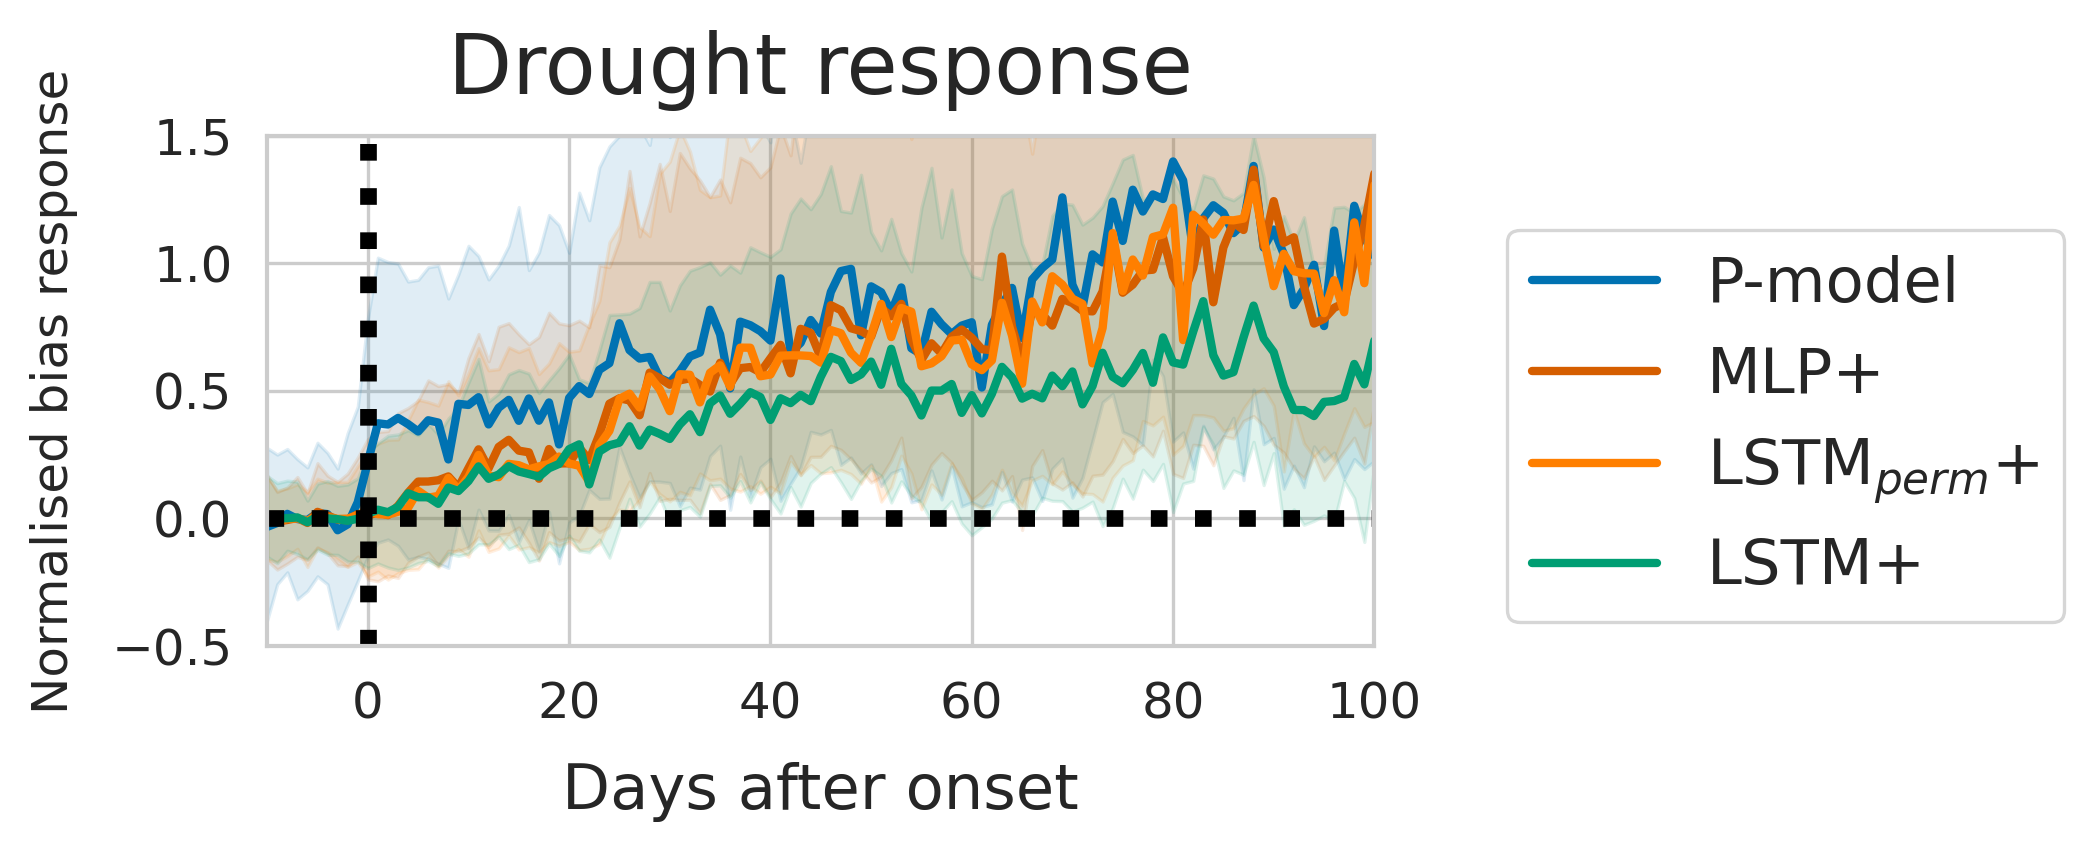

In [28]:
set_publication_style(figsize=(8,3))
fig, ax = plt.subplots(1, 1, figsize=(5,3), sharey=True)

xlim=(-10, 100)
ylim=(-0.5, 1.5)

# Drought panel
for lab, dct in zip(model_labels, outputs_drought):
    da = _agg_to_y(dct).sort_values("dday")
    ax.fill_between(da["dday"], da["y_lo"], da["y_hi"], alpha=0.12, label=None, color=colors[lab])
    ax.plot(da["dday"], da["y_med"], lw=2, label=lab, color=colors[lab])
ax.axhline(0, ls=":", c="k"); ax.axvline(0, ls=":", c="k")
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_title("Drought response")
ax.set_xlabel("Days after onset")
ax.set_ylabel(r"Normalised bias response", fontsize=12)

# Legend to the right of the plot
handles, labels_leg = ax.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()

# plt.savefig('figures/6_events.png')

plt.show()


## Figure 7: Spatial patterns in model performance

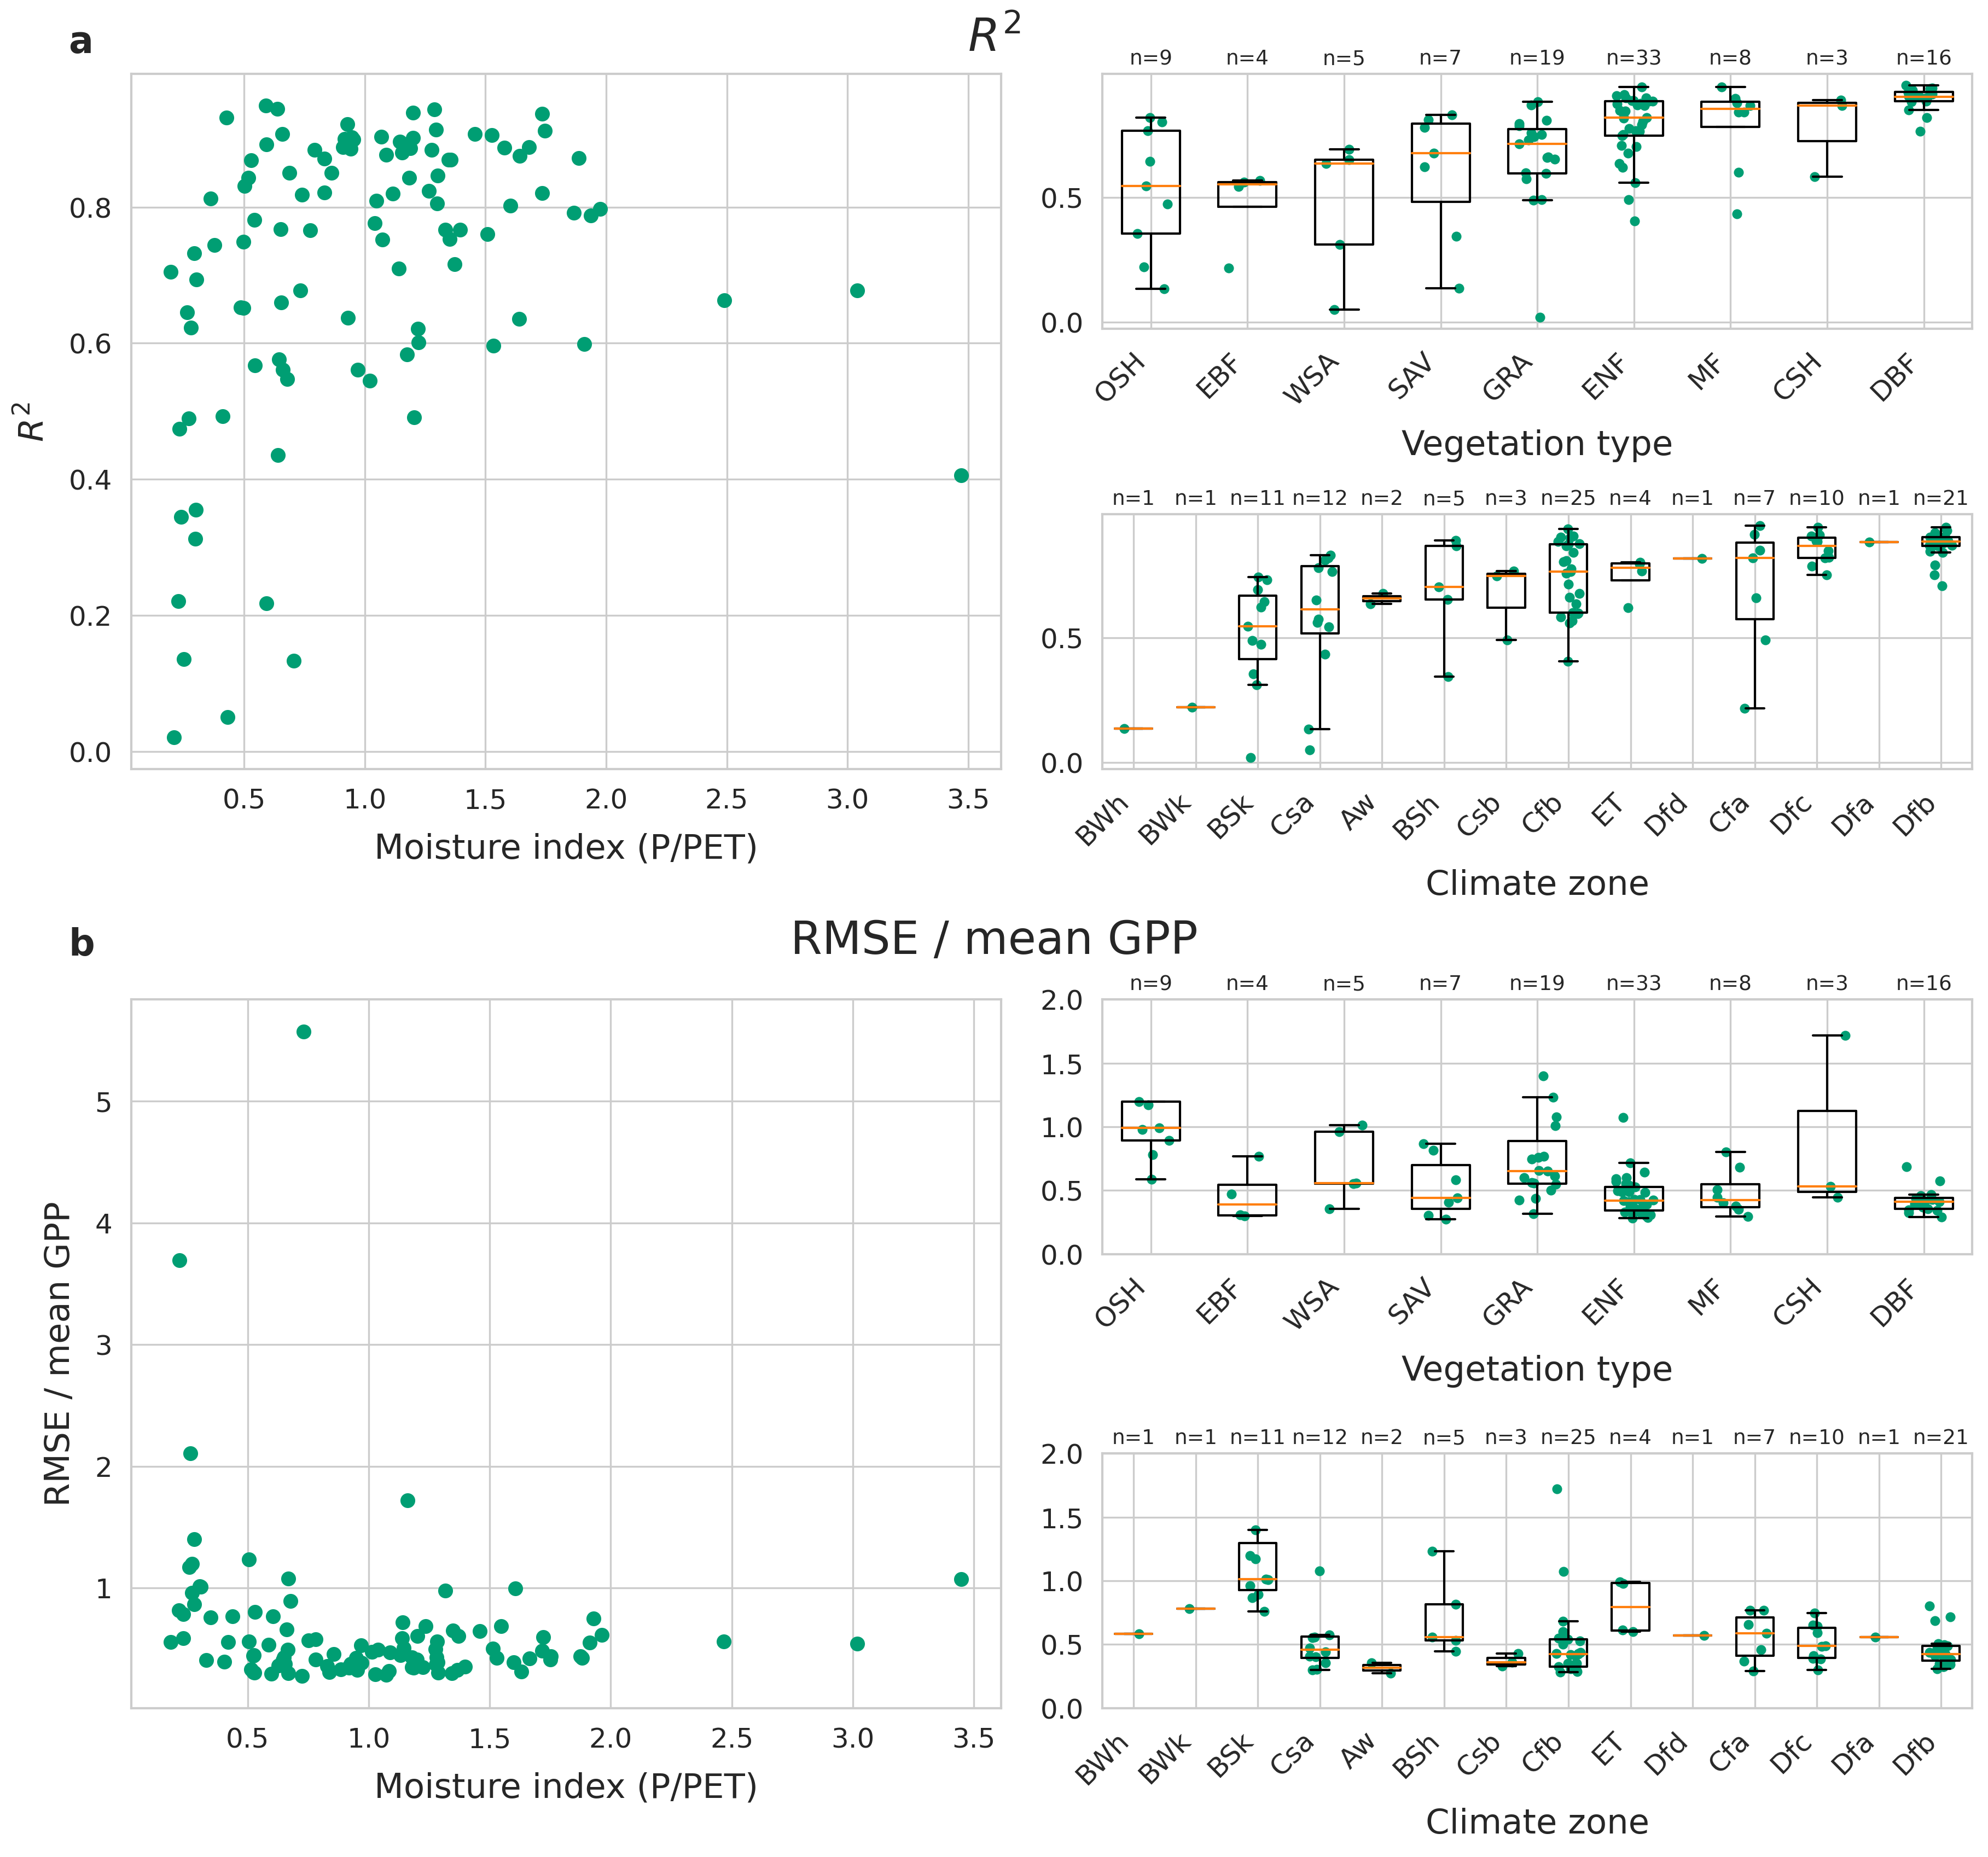

In [29]:
set_publication_style()
df_subset = site_metrics_df.copy()
col_rmse = "lstm_global_plus_rmse"
col_r2 = "lstm_global_plus_r2"
df_subset["rmse_norm"] = df_subset[col_rmse] / df_subset["mean_gpp"]
veg_medians = df_subset.groupby("igbp_land_use")[col_r2].median()
veg_order = veg_medians.sort_values().index.tolist()
climate_medians = df_subset.groupby("koeppen_code")[col_r2].median()
climate_order = climate_medians.sort_values().index.tolist()

layout = [
    ["r2_moist", "r2_veg"],
    ["r2_moist", "r2_clim"],
    ["SPACER",   "SPACER"],
    ["rmse_moist", "rmse_veg"],
    ["rmse_moist", "rmse_clim"],
]
fig, axd = plt.subplot_mosaic(layout, figsize=(12, 11), constrained_layout=True, gridspec_kw={"height_ratios": [1, 1, 0.18, 1, 1]})
ax_r2_moisture = axd["r2_moist"]
ax_r2_veg = axd["r2_veg"]
ax_r2_climate = axd["r2_clim"]
ax_rmse_moisture = axd["rmse_moist"]
ax_rmse_veg = axd["rmse_veg"]
ax_rmse_climate = axd["rmse_clim"]

ai_values = df_subset["ai"]
r2_values = df_subset[col_r2]
for ai, val in zip(ai_values, r2_values):
    if pd.notna(val):
        ax_r2_moisture.scatter(ai + np.random.uniform(-0.02, 0.02), val, color=colors["LSTM+"], marker=".", s=130)
ax_r2_moisture.set_ylabel(r"$R^2$")
ax_r2_moisture.set_xlabel("Moisture index (P/PET)")

ax_sp = axd["SPACER"]
ax_sp.axis("off")

data_r2_veg = [df_subset.loc[df_subset["igbp_land_use"] == cat, col_r2].dropna() for cat in veg_order]
x_positions = np.arange(len(data_r2_veg))
ax_r2_veg.boxplot(data_r2_veg, positions=x_positions, widths=0.6, showfliers=False)
for i, d in enumerate(data_r2_veg):
    if len(d) > 0:
        ax_r2_veg.scatter(np.full(len(d), i) + np.random.uniform(-0.2, 0.2, len(d)), d, color=colors["LSTM+"], marker=".", s=50)
ax_r2_veg.set_xticks(x_positions)
ax_r2_veg.set_xticklabels(veg_order, rotation=45, ha="right")
ax_r2_veg.set_xlabel("Vegetation type")

data_r2_climate = [df_subset.loc[df_subset["koeppen_code"] == cat, col_r2].dropna() for cat in climate_order]
x_positions = np.arange(len(data_r2_climate))
ax_r2_climate.boxplot(data_r2_climate, positions=x_positions, widths=0.6, showfliers=False)
for i, d in enumerate(data_r2_climate):
    if len(d) > 0:
        ax_r2_climate.scatter(np.full(len(d), i) + np.random.uniform(-0.2, 0.2, len(d)), d, color=colors["LSTM+"], marker=".", s=50)
ax_r2_climate.set_xticks(x_positions)
ax_r2_climate.set_xticklabels(climate_order, rotation=45, ha="right")
ax_r2_climate.set_xlabel("Climate zone")

rmse_values = df_subset["rmse_norm"]
for ai, val in zip(ai_values, rmse_values):
    if pd.notna(val):
        ax_rmse_moisture.scatter(ai + np.random.uniform(-0.02, 0.02), val, color=colors["LSTM+"], marker=".", s=130)
ax_rmse_moisture.set_ylabel("RMSE / mean GPP")
ax_rmse_moisture.set_xlabel("Moisture index (P/PET)")

data_rmse_veg = [df_subset.loc[df_subset["igbp_land_use"] == cat, "rmse_norm"].dropna() for cat in veg_order]
x_positions = np.arange(len(data_rmse_veg))
ax_rmse_veg.boxplot(data_rmse_veg, positions=x_positions, widths=0.6, showfliers=False)
for i, d in enumerate(data_rmse_veg):
    if len(d) > 0:
        ax_rmse_veg.scatter(np.full(len(d), i) + np.random.uniform(-0.2, 0.2, len(d)), d, color=colors["LSTM+"], marker=".", s=50)
ax_rmse_veg.set_xticks(x_positions)
ax_rmse_veg.set_xticklabels(veg_order, rotation=45, ha="right")
ax_rmse_veg.set_xlabel("Vegetation type")

data_rmse_climate = [df_subset.loc[df_subset["koeppen_code"] == cat, "rmse_norm"].dropna() for cat in climate_order]
x_positions = np.arange(len(data_rmse_climate))
ax_rmse_climate.boxplot(data_rmse_climate, positions=x_positions, widths=0.6, showfliers=False)
for i, d in enumerate(data_rmse_climate):
    if len(d) > 0:
        ax_rmse_climate.scatter(np.full(len(d), i) + np.random.uniform(-0.2, 0.2, len(d)), d, color=colors["LSTM+"], marker=".", s=50)
ax_rmse_climate.set_xticks(x_positions)
ax_rmse_climate.set_xticklabels(climate_order, rotation=45, ha="right")
ax_rmse_climate.set_xlabel("Climate zone")

ax_rmse_veg.set_ylim(0, 2)
ax_rmse_climate.set_ylim(0, 2)

def annotate_ns(ax, xs, ns, y_axes=1.02, fontsize=9):
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    for x, n in zip(xs, ns):
        ax.text(x, y_axes, f"n={n}", transform=trans, ha="center", va="bottom", fontsize=fontsize)

annotate_ns(ax_r2_veg, np.arange(len(data_r2_veg)), [len(d) for d in data_r2_veg])
annotate_ns(ax_r2_climate, np.arange(len(data_r2_climate)), [len(d) for d in data_r2_climate])
annotate_ns(ax_rmse_veg, np.arange(len(data_rmse_veg)), [len(d) for d in data_rmse_veg])
annotate_ns(ax_rmse_climate, np.arange(len(data_rmse_climate)), [len(d) for d in data_rmse_climate])

fig.text(0.03, 1, "a", ha="left", va="center", fontsize=16, fontweight="heavy", fontfamily="sans-serif")
fig.text(0.03, 0.5, "b", ha="left", va="center", fontsize=16, fontweight="heavy", fontfamily="sans-serif")
fig.text(0.5, 0.99, r"$R^2$", ha="center", va="bottom", fontsize=20)
fig.text(0.5, 0.49, "RMSE / mean GPP", ha="center", va="bottom", fontsize=20)

# plt.savefig('figures/7_globallstm.png')

plt.show()


## Figure 8: Generalisation across space

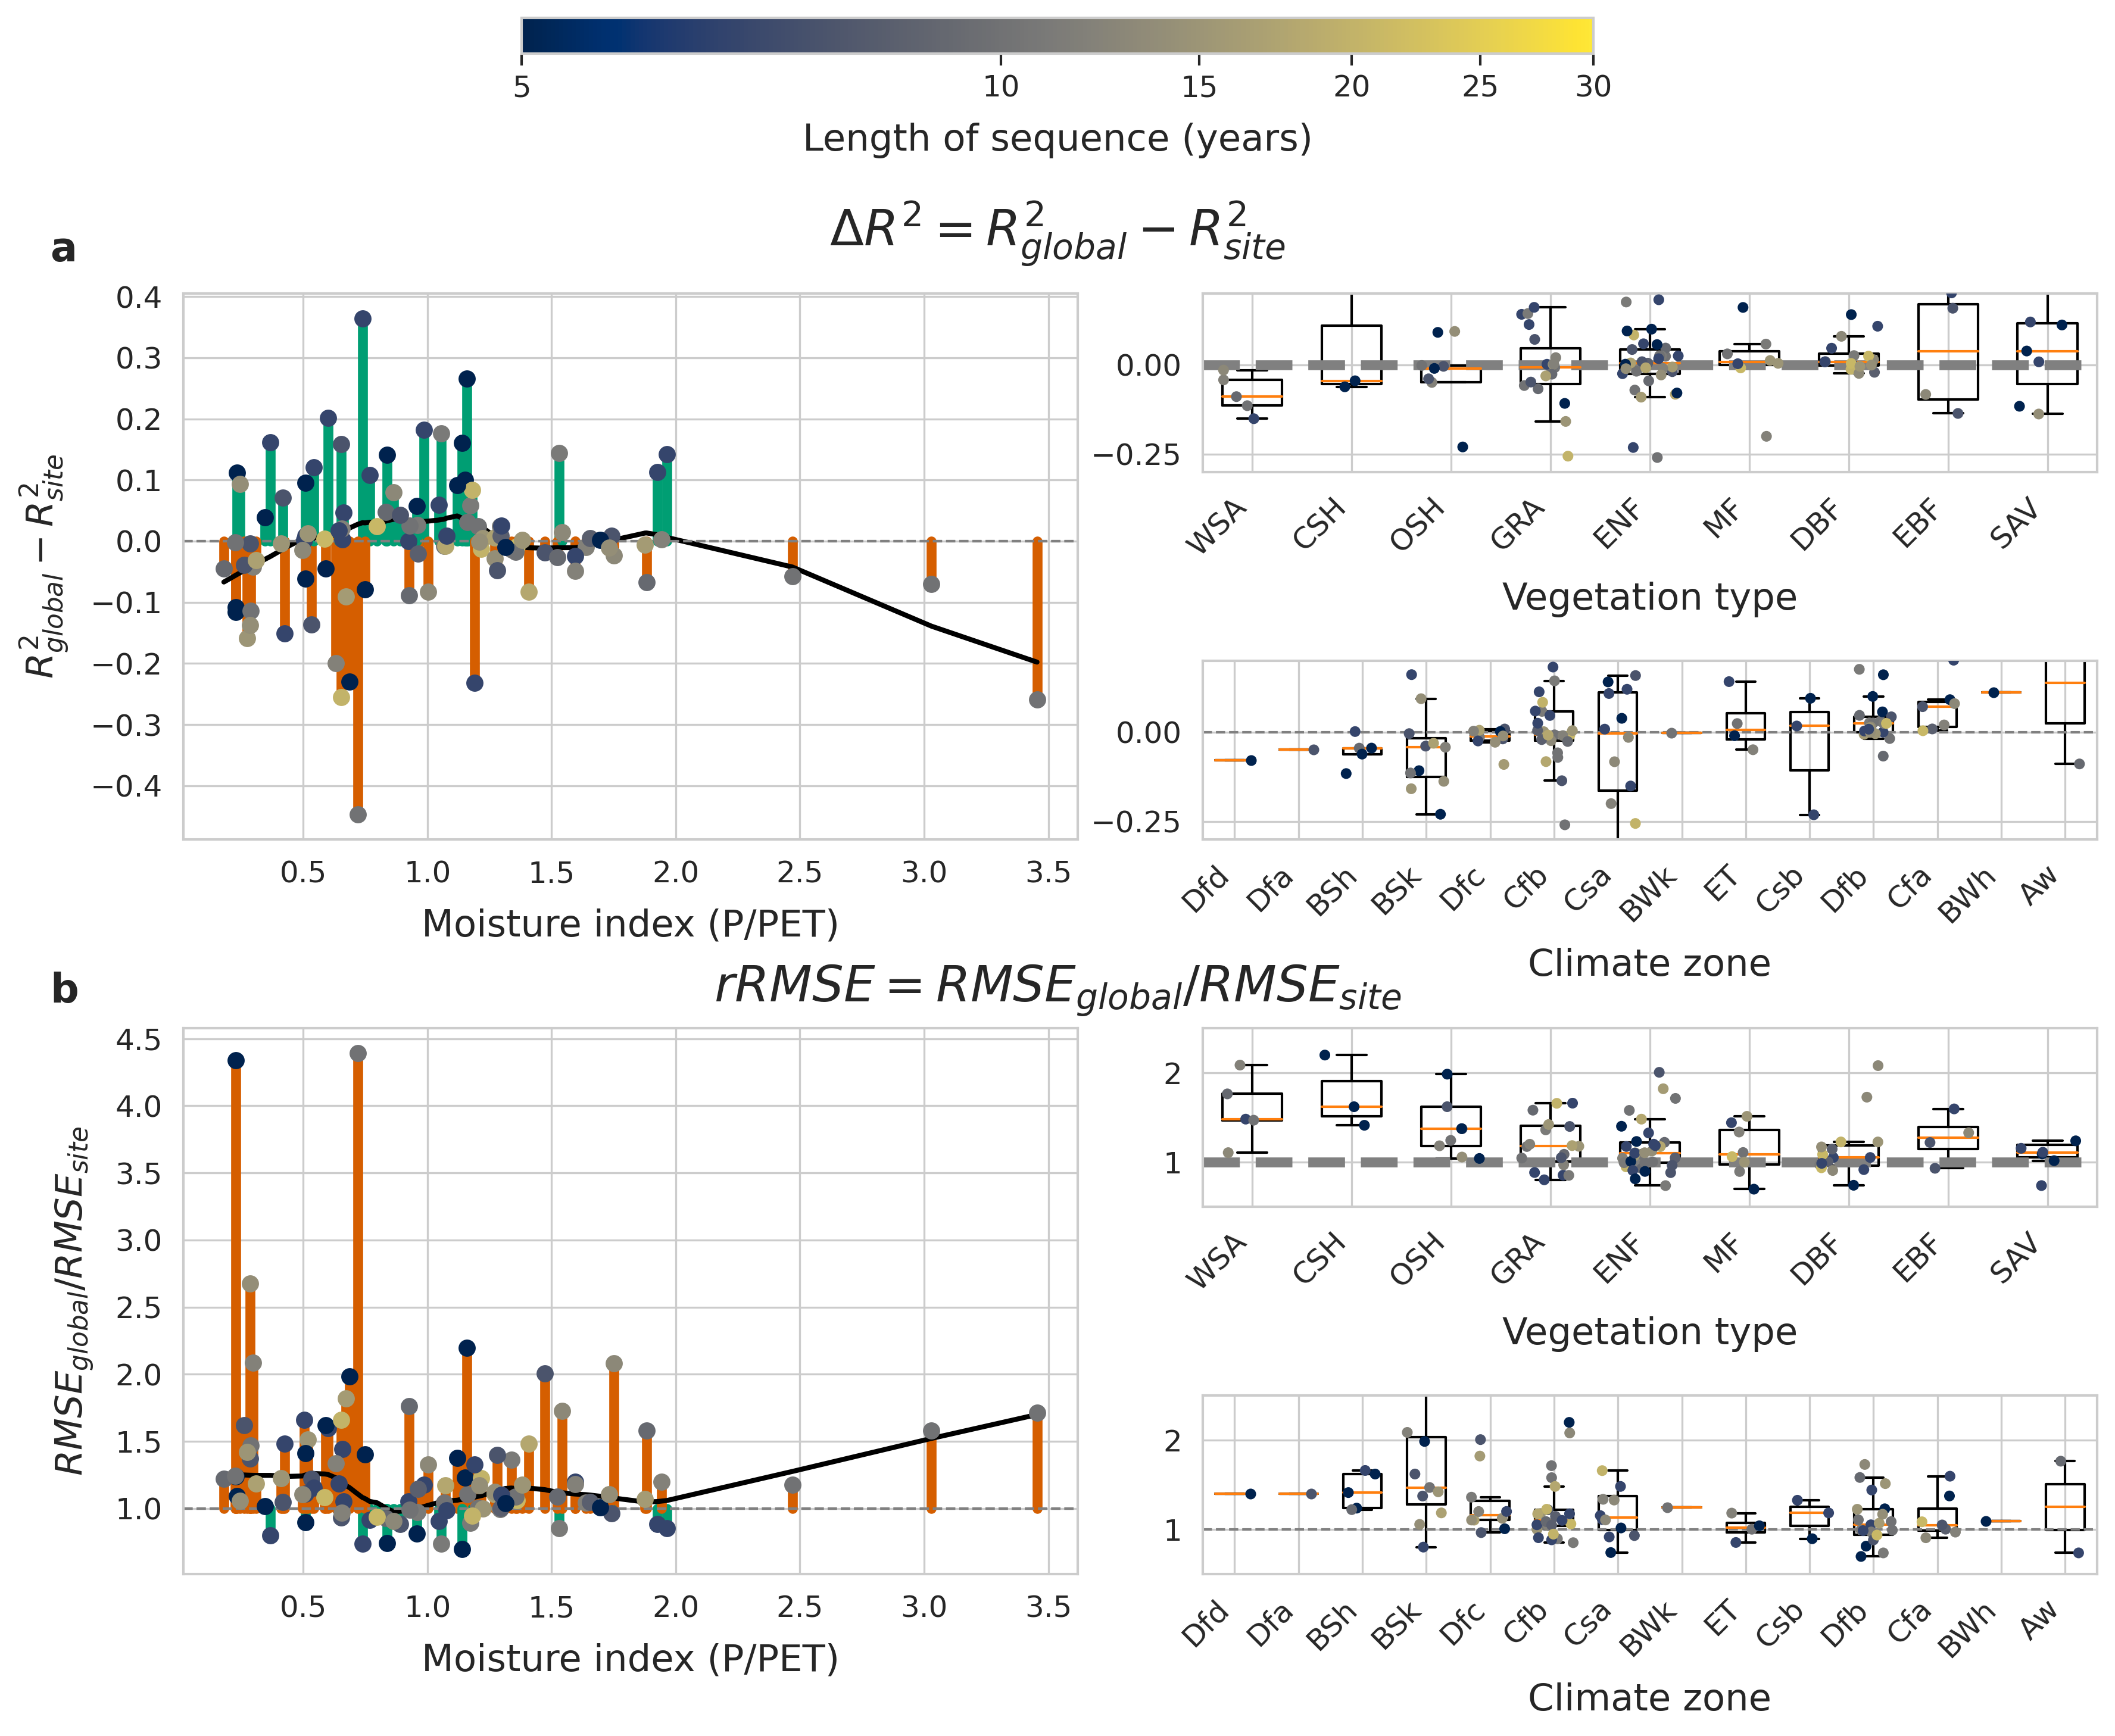

In [30]:
set_publication_style()
df_subset = site_metrics_df.copy()
df_subset['n_days'] = df.groupby('sitename').size().values
n_years = df_subset['n_days'] / 365

r2_first_values = df_subset['metrics_diff_global_site_lstm_r2']
veg_medians = df_subset.groupby('igbp_land_use')[r2_first_values.name].median()
veg_order = veg_medians.sort_values().index.tolist()
climate_medians = df_subset.groupby('koeppen_code')[r2_first_values.name].median()
climate_order = climate_medians.sort_values().index.tolist()

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(4, 2, height_ratios=[1, 1, 1, 1])
ax_r2_moisture = fig.add_subplot(gs[0:2, 0])
ax_r2_veg = fig.add_subplot(gs[0, 1])
ax_r2_climate = fig.add_subplot(gs[1, 1])
ax_rmse_moisture = fig.add_subplot(gs[2:4, 0])
ax_rmse_veg = fig.add_subplot(gs[2, 1])
ax_rmse_climate = fig.add_subplot(gs[3, 1])
ai_values = df_subset['ai']

cmap = plt.cm.cividis
norm = plt.Normalize(vmin=n_years.min(), vmax=n_years.max())
norm = plt_colors.PowerNorm(gamma=0.5, vmin=5, vmax=30)

metric_names = ['r2', 'rmse']
for idx, metric in enumerate(metric_names):
    if metric == 'r2':
        first_values = df_subset['metrics_diff_global_site_lstm_r2']
        baseline = 0
        ylabel = r'$R^2_{global} - R^2_{site}$'
        ax_moist = ax_r2_moisture
        ax_veg = ax_r2_veg
        ax_climate = ax_r2_climate
    elif metric == 'rmse':
        first_values = df_subset['metrics_diff_global_site_lstm_rmse']
        baseline = 1
        ylabel = r'$RMSE_{global} / RMSE_{site}$'
        ax_moist = ax_rmse_moisture
        ax_veg = ax_rmse_veg
        ax_climate = ax_rmse_climate

    x_vals, y_vals = [], []
    for aiv, val, yrs in zip(ai_values, first_values, n_years):
        if pd.notnull(val):
            lc = '#009E73' if (metric == 'r2' and val > 0) or (metric == 'rmse' and val < baseline) else '#D55E00'
            ax_moist.plot([aiv, aiv], [baseline, val], color=lc)
            ax_moist.scatter(aiv, val, color=cmap(norm(yrs)), marker='.', s=150, zorder=3)
            x_vals.append(aiv)
            y_vals.append(val)

    ax_moist.axhline(y=baseline, color='gray', linestyle='--', linewidth=1)
    ax_moist.set_xlabel('Moisture index (P/PET)')
    ax_moist.set_ylabel(ylabel)

    if len(x_vals) > 0:
        loess_result = sm.nonparametric.lowess(y_vals, x_vals, frac=0.3, return_sorted=True)
        ax_moist.plot(loess_result[:, 0], loess_result[:, 1], color='black', linewidth=2, label='LOWESS')
    ax_moist.axhline(y=baseline, color='gray', linestyle='--', linewidth=1)
    ax_moist.set_xlabel('Moisture index (P/PET)')
    ax_moist.set_ylabel(ylabel)

    data_veg = [df_subset.loc[df_subset['igbp_land_use'] == cat, first_values.name].dropna() for cat in veg_order]
    x_veg = np.arange(len(data_veg))
    ax_veg.boxplot(data_veg, positions=x_veg, widths=0.6, showfliers=False)
    for i, cat in enumerate(veg_order):
        subset = df_subset[df_subset['igbp_land_use'] == cat]
        subset = subset[subset[first_values.name].notnull()]
        if not subset.empty:
            x_vals = np.full(len(subset), i) + np.random.uniform(-0.3, 0.3, len(subset))
            tmp_colors = cmap(norm(subset['n_days'] / 365))
            ax_veg.scatter(x_vals, subset[first_values.name], color=tmp_colors, marker='.', s=50, zorder=3)
    ax_veg.axhline(y=baseline, color='gray', linestyle='--')
    ax_veg.set_xticks(x_veg)
    ax_veg.set_xticklabels(veg_order, rotation=45, ha='right')
    ax_veg.set_xlabel('Vegetation type')

    data_climate = [df_subset.loc[df_subset['koeppen_code'] == cat, first_values.name].dropna() for cat in climate_order]
    x_climate = np.arange(len(data_climate))
    ax_climate.boxplot(data_climate, positions=x_climate, widths=0.6, showfliers=False)
    for i, cat in enumerate(climate_order):
        subset = df_subset[df_subset['koeppen_code'] == cat]
        subset = subset[subset[first_values.name].notnull()]
        if not subset.empty:
            x_vals = np.full(len(subset), i) + np.random.uniform(-0.3, 0.3, len(subset))
            tmp_colors = cmap(norm(subset['n_days'] / 365))
            ax_climate.scatter(x_vals, subset[first_values.name], color=tmp_colors, marker='.', s=50, zorder=3)
    ax_climate.axhline(y=baseline, color='gray', linestyle='--', linewidth=1)
    ax_climate.set_xticks(x_climate)
    ax_climate.set_xticklabels(climate_order, rotation=45, ha='right')
    ax_climate.set_xlabel('Climate zone')

    if metric == 'r2':
        ax_veg.set_ylim(-0.3, 0.2)
        ax_climate.set_ylim(-0.3, 0.2)
    elif metric == 'rmse':
        ax_veg.set_ylim(0.5, 2.5)
        ax_climate.set_ylim(0.5, 2.5)

fig.text(0.03, 0.84, 'a', ha='left', va='center', fontsize=16, fontweight='heavy', fontfamily='sans-serif')
fig.text(0.03, 0.425, 'b', ha='left', va='center', fontsize=16, fontweight='heavy', fontfamily='sans-serif')
plt.tight_layout(rect=[0, 0, 1, 0.84])
fig.text(0.5, 0.83, r'$\Delta R^2 = R^2_{global} - R^2_{site}$', ha='center', va='bottom', fontsize=20)
fig.text(0.5, 0.41, r'$rRMSE = RMSE_{global} / RMSE_{site}$', ha='center', va='bottom', fontsize=20)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.25, 0.95, 0.5, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Length of sequence (years)')

# plt.savefig('figures/8_generalisation.png')

plt.show()

## Figure 9: Generalisation comparison

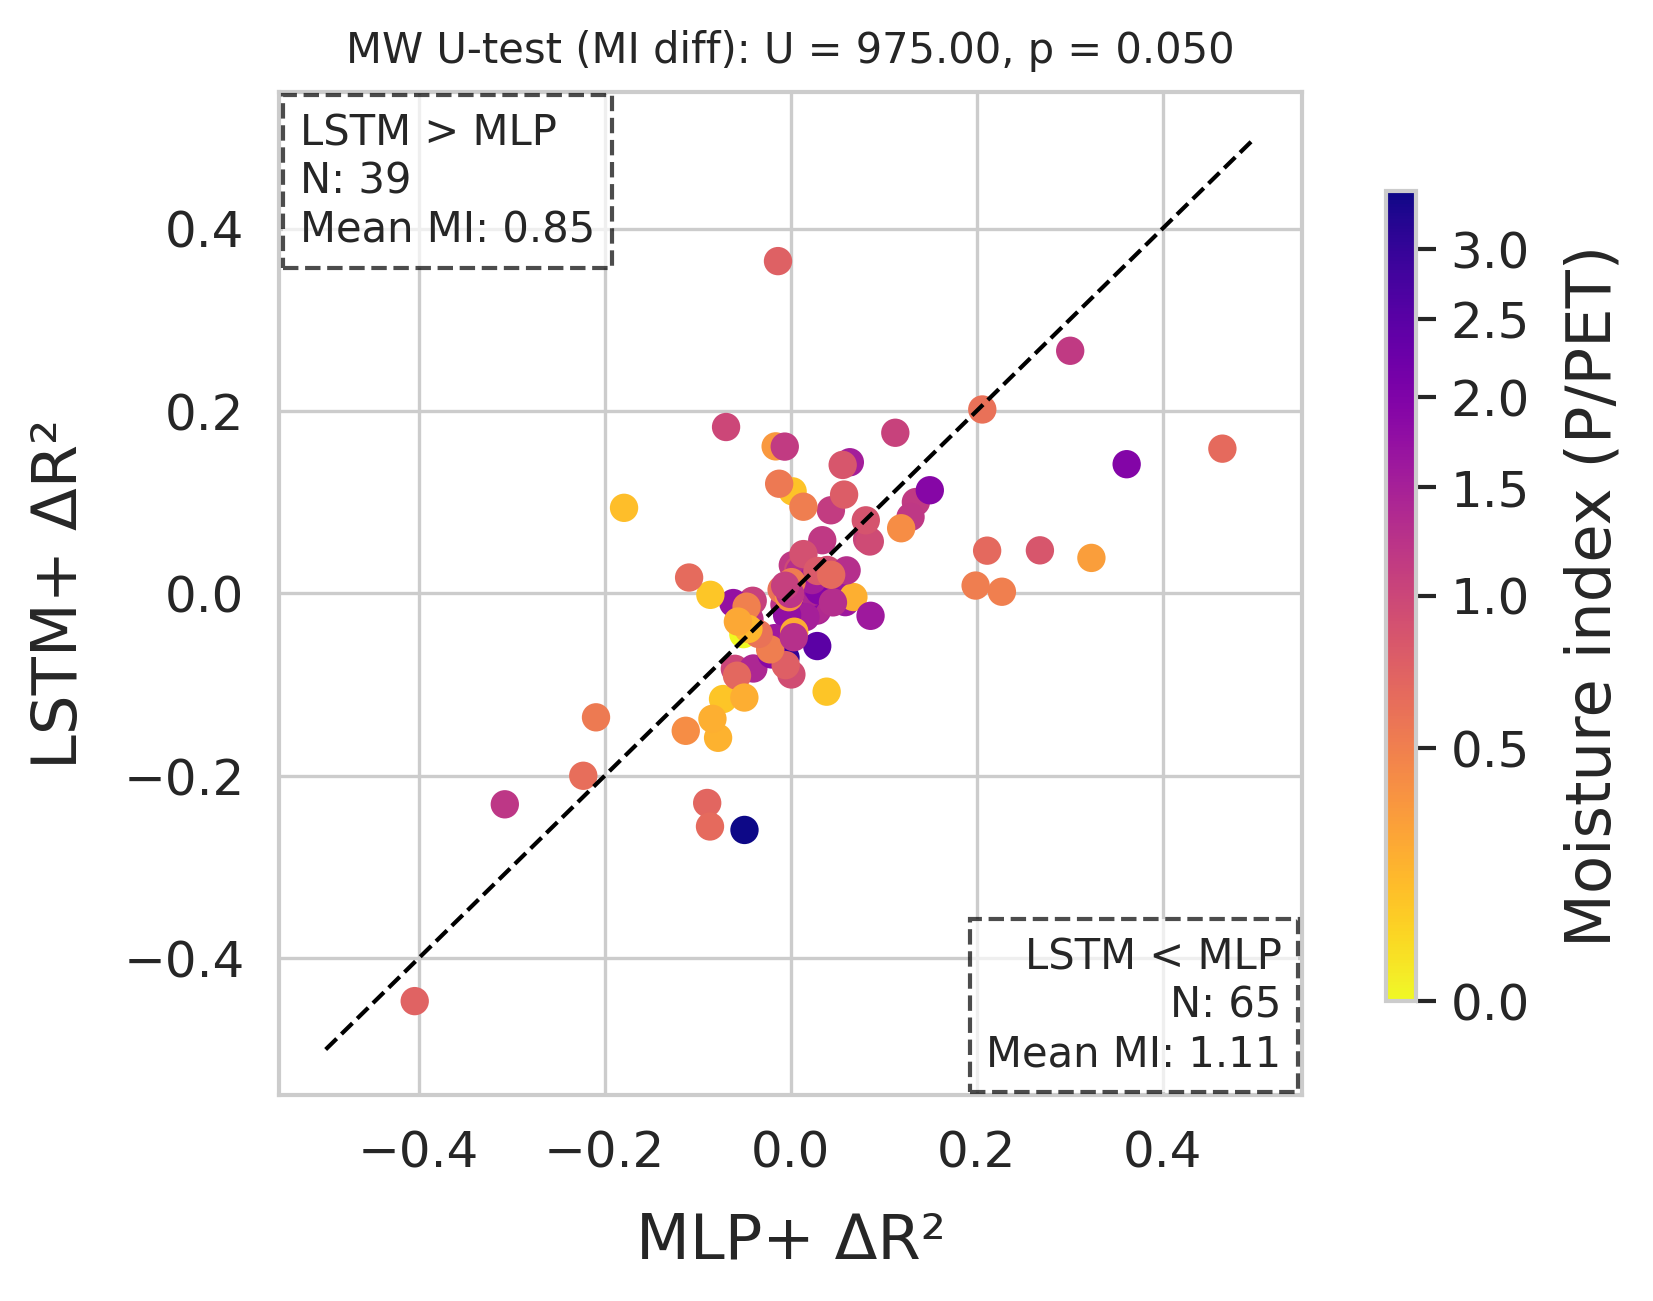

In [31]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from scipy import stats

def compare_models(df, model_a, model_b, ai_col="ai", cmap="plasma_r", gamma=0.5):
    norm = PowerNorm(gamma=gamma, vmin=df[ai_col].min(), vmax=df[ai_col].max())
    diff_a = f"metrics_diff_global_site_{model_a}_r2"
    diff_b = f"metrics_diff_global_site_{model_b}_r2"

    n_a_gt_b = (df[diff_a] > df[diff_b]).sum()
    mean_ai_a_gt_b = df[df[diff_a] > df[diff_b]][ai_col].mean()
    n_a_lt_b = (df[diff_a] < df[diff_b]).sum()
    mean_ai_a_lt_b = df[df[diff_a] < df[diff_b]][ai_col].mean()

    fig, ax = plt.subplots(1, 1, figsize=(5, 4.5))
    sc = ax.scatter(df[diff_b], df[diff_a], c=df[ai_col], cmap=cmap, norm=norm)
    ax.plot([-0.5, 0.5], [-0.5, 0.5], "k--", lw=1)
    ax.set_xlabel(f"{model_b.upper()}+ ΔR²")
    ax.set_ylabel(f"{model_a.upper()}+ ΔR²")

    text_a_gt_b = f"{model_a.upper()} > {model_b.upper()}\nN: {n_a_gt_b}\nMean MI: {mean_ai_a_gt_b:.2f}"
    text_a_lt_b = f"{model_a.upper()} < {model_b.upper()}\nN: {n_a_lt_b}\nMean MI: {mean_ai_a_lt_b:.2f}"
    bbox_props = dict(facecolor='white', alpha=0.7, edgecolor='black', linestyle='dashed', linewidth=1)
    ax.text(0.02, 0.98, text_a_gt_b, transform=ax.transAxes, ha='left', va='top', fontsize=10, bbox=bbox_props)
    ax.text(0.98, 0.02, text_a_lt_b, transform=ax.transAxes, ha='right', va='bottom', fontsize=10, bbox=bbox_props)

    group_a_gt_b = df[df[diff_a] > df[diff_b]][ai_col]
    group_a_lt_b = df[df[diff_a] < df[diff_b]][ai_col]
    stat, p_val = stats.mannwhitneyu(group_a_gt_b, group_a_lt_b, alternative='two-sided')
    ax.text(0.5, 1.02, f"MW U-test (MI diff): U = {stat:.2f}, p = {p_val:.3f}", transform=ax.transAxes, ha='center', va='bottom', fontsize=10)

    plt.tight_layout(rect=[0, 0, 0.92, 1])
    cbar_ax = fig.add_axes([0.94, 0.24, 0.02, 0.6])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label("Moisture index (P/PET)")

    # plt.savefig('figures/9_comparison_generalisation.png')

    plt.show()

compare_models(site_metrics_df, "lstm", "mlp")


## Figure 10: Performance with additional features

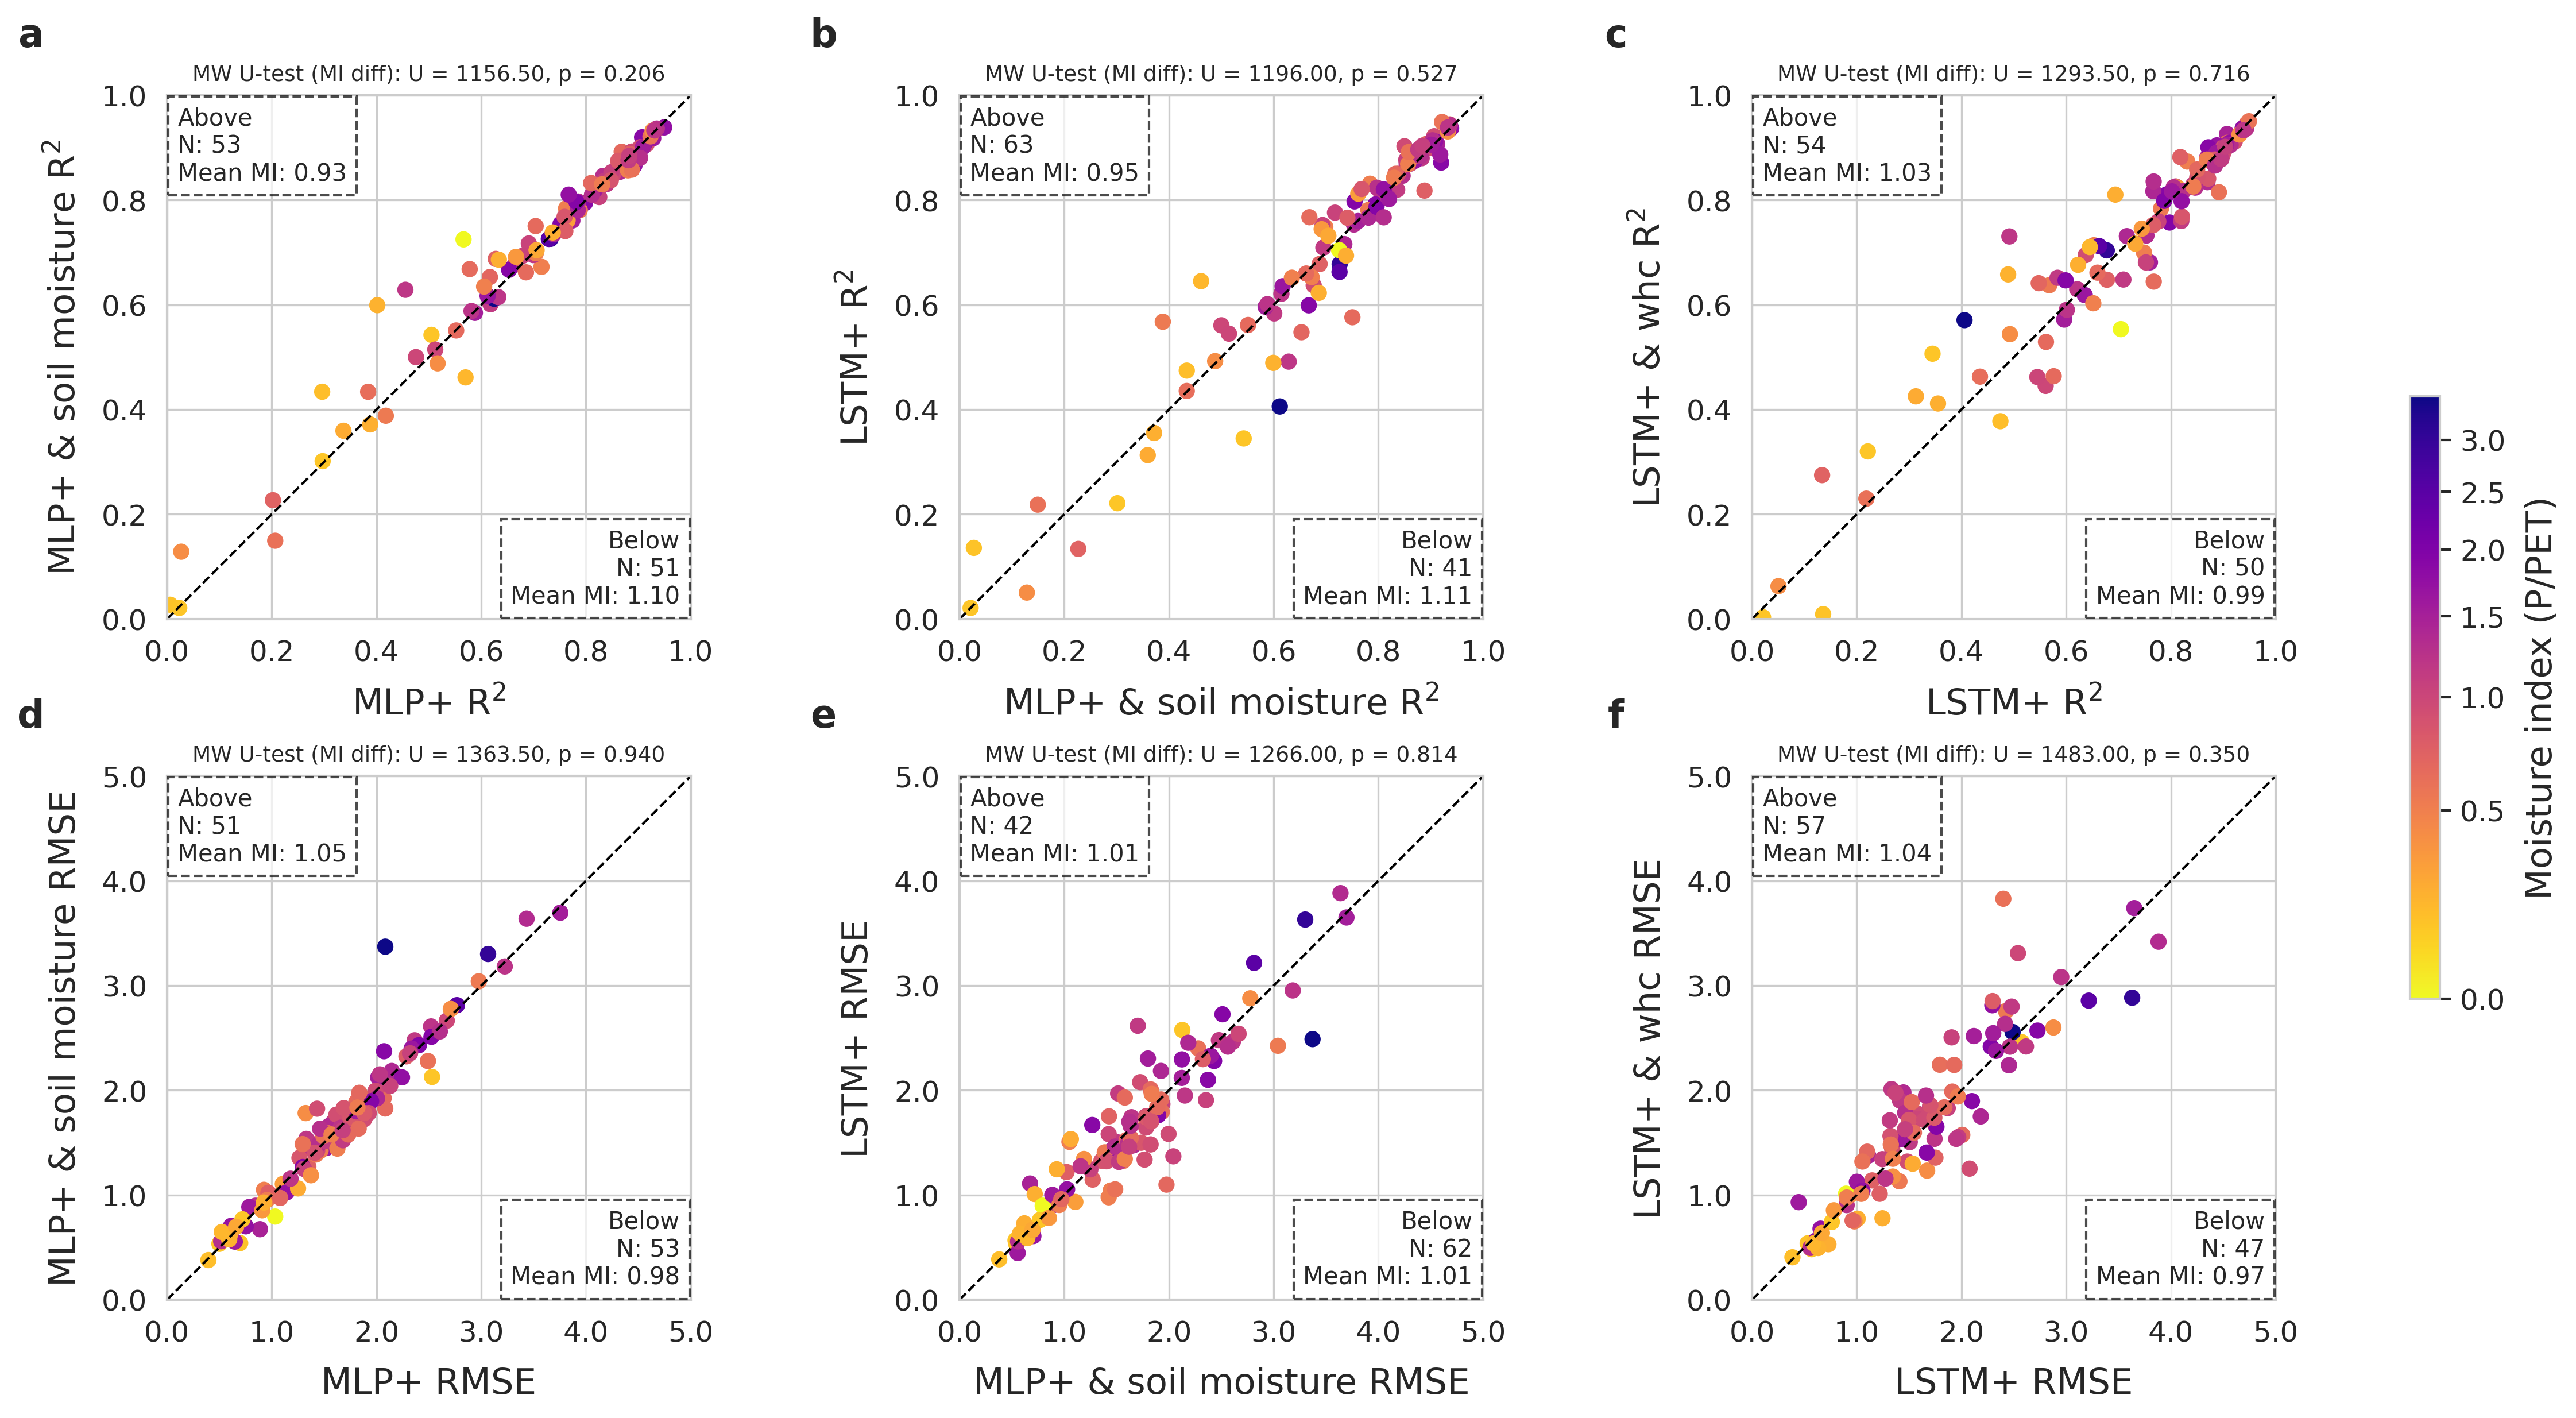

In [32]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from scipy import stats

set_publication_style()
df_subset = site_metrics_df.copy()
norm = PowerNorm(gamma=0.5, vmin=df_subset["ai"].min(), vmax=df_subset["ai"].max())

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

sc = axes[0,0].scatter(df_subset["mlp_global_plus_r2"], df_subset["mlp_global_extra_plus_r2"], c=df_subset["ai"], cmap="plasma_r", norm=norm, marker="o")
axes[0,0].plot([0,1], [0,1], "k--", lw=1)
axes[0,0].set_xlim(0,1); axes[0,0].set_ylim(0,1)
axes[0,0].set_xticks([0,0.2,0.4,0.6,0.8,1]); axes[0,0].set_yticks([0,0.2,0.4,0.6,0.8,1])
axes[0,0].set_xlabel(r"MLP+ R$^2$"); axes[0,0].set_ylabel(r"MLP+ & soil moisture R$^2$")

sc = axes[0,1].scatter(df_subset["mlp_global_extra_plus_r2"], df_subset["lstm_global_plus_r2"], c=df_subset["ai"], cmap="plasma_r", norm=norm, marker="o")
axes[0,1].plot([0,1], [0,1], "k--", lw=1)
axes[0,1].set_xlim(0,1); axes[0,1].set_ylim(0,1)
axes[0,1].set_xticks([0,0.2,0.4,0.6,0.8,1]); axes[0,1].set_yticks([0,0.2,0.4,0.6,0.8,1])
axes[0,1].set_xlabel(r"MLP+ & soil moisture R$^2$"); axes[0,1].set_ylabel(r"LSTM+ R$^2$")

sc = axes[0,2].scatter(df_subset["lstm_global_plus_r2"], df_subset["lstm_global_extra_plus_r2"], c=df_subset["ai"], cmap="plasma_r", norm=norm, marker="o")
axes[0,2].plot([0,1], [0,1], "k--", lw=1)
axes[0,2].set_xlim(0,1); axes[0,2].set_ylim(0,1)
axes[0,2].set_xticks([0,0.2,0.4,0.6,0.8,1]); axes[0,2].set_yticks([0,0.2,0.4,0.6,0.8,1])
axes[0,2].set_xlabel(r"LSTM+ R$^2$"); axes[0,2].set_ylabel(r"LSTM+ & whc R$^2$")

sc = axes[1,0].scatter(df_subset["mlp_global_plus_rmse"], df_subset["mlp_global_extra_plus_rmse"], c=df_subset["ai"], cmap="plasma_r", norm=norm, marker="o")
axes[1,0].plot([0,5], [0,5], "k--", lw=1)
axes[1,0].set_xlim(0,5); axes[1,0].set_ylim(0,5)
axes[1,0].set_xticks(range(6)); axes[1,0].set_yticks(range(6))
axes[1,0].set_xticklabels([f"{tick:.1f}" for tick in range(6)])
axes[1,0].set_yticklabels([f"{tick:.1f}" for tick in range(6)])
axes[1,0].set_xlabel(r"MLP+ RMSE"); axes[1,0].set_ylabel(r"MLP+ & soil moisture RMSE")

sc = axes[1,1].scatter(df_subset["mlp_global_extra_plus_rmse"], df_subset["lstm_global_plus_rmse"], c=df_subset["ai"], cmap="plasma_r", norm=norm, marker="o")
axes[1,1].plot([0,5], [0,5], "k--", lw=1)
axes[1,1].set_xlim(0,5); axes[1,1].set_ylim(0,5)
axes[1,1].set_xticks(range(6)); axes[1,1].set_yticks(range(6))
axes[1,1].set_xticklabels([f"{tick:.1f}" for tick in range(6)])
axes[1,1].set_yticklabels([f"{tick:.1f}" for tick in range(6)])
axes[1,1].set_xlabel(r"MLP+ & soil moisture RMSE"); axes[1,1].set_ylabel(r"LSTM+ RMSE")

sc = axes[1,2].scatter(df_subset["lstm_global_plus_rmse"], df_subset["lstm_global_extra_plus_rmse"], c=df_subset["ai"], cmap="plasma_r", norm=norm, marker="o")
axes[1,2].plot([0,5], [0,5], "k--", lw=1)
axes[1,2].set_xlim(0,5); axes[1,2].set_ylim(0,5)
axes[1,2].set_xticks(range(6)); axes[1,2].set_yticks(range(6))
axes[1,2].set_xticklabels([f"{tick:.1f}" for tick in range(6)])
axes[1,2].set_yticklabels([f"{tick:.1f}" for tick in range(6)])
axes[1,2].set_xlabel(r"LSTM+ RMSE"); axes[1,2].set_ylabel(r"LSTM+ & whc RMSE")

for ax in axes.flatten():
    ax.set_aspect("equal", adjustable="box")

fig.tight_layout()
fig.subplots_adjust(right=0.88, wspace=0.4, hspace=0.3)

letters = ["a","b","c","d","e","f","g","h"]
for ax, letter in zip(axes.flatten(), letters):
    ax.text(-0.26, 1.15, letter, transform=ax.transAxes, fontsize=16, fontweight="heavy", fontfamily="sans-serif", va="top", ha="center", clip_on=False)

plots_info = [
    (axes[0,0], "mlp_global_plus_r2", "mlp_global_extra_plus_r2"),
    (axes[0,1], "mlp_global_extra_plus_r2", "lstm_global_plus_r2"),
    (axes[0,2], "lstm_global_plus_r2", "lstm_global_extra_plus_r2"),
    (axes[1,0], "mlp_global_plus_rmse", "mlp_global_extra_plus_rmse"),
    (axes[1,1], "mlp_global_extra_plus_rmse", "lstm_global_plus_rmse"),
    (axes[1,2], "lstm_global_plus_rmse", "lstm_global_extra_plus_rmse"),
]

bbox_props = dict(facecolor='white', alpha=0.7, edgecolor='black', linestyle='dashed', linewidth=1)
for ax, x_col, y_col in plots_info:
    above_mask = df_subset[y_col] > df_subset[x_col]
    below_mask = df_subset[y_col] < df_subset[x_col]
    above_count = above_mask.sum(); below_count = below_mask.sum()
    mean_ai_above = df_subset.loc[above_mask, "ai"].mean()
    mean_ai_below = df_subset.loc[below_mask, "ai"].mean()
    ax.text(0.02, 0.98, f"Above\nN: {above_count}\nMean MI: {mean_ai_above:.2f}", transform=ax.transAxes, ha='left', va='top', fontsize=10, bbox=bbox_props)
    ax.text(0.98, 0.02, f"Below\nN: {below_count}\nMean MI: {mean_ai_below:.2f}", transform=ax.transAxes, ha='right', va='bottom', fontsize=10, bbox=bbox_props)
    stat, p_val = stats.mannwhitneyu(df_subset.loc[above_mask,"ai"], df_subset.loc[below_mask,"ai"], alternative='two-sided')
    ax.text(0.5, 1.02, f"MW U-test (MI diff): U = {stat:.2f}, p = {p_val:.3f}", transform=ax.transAxes, ha='center', va='bottom', fontsize=9)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.5)
cbar.set_label("Moisture index (P/PET)")

# plt.savefig('figures/10_soilmoisture.png')

plt.show()



## Appendix

In [33]:
site_metrics_df['delayed_gpp'] = site_metrics_df['cold_acclimation_type'].apply(lambda x: True if x == 'cold_delayedgpp' else (False if x == 'cold_nodelayedgpp' else ''))
site_metrics_df['ai'] = site_metrics_df['ai'].round(2)
site_metrics_df['period'] = site_metrics_df['start_year'].astype(str) + '-' + site_metrics_df['end_year'].astype(str)
site_metrics_df['reference?'] = ''
df_renamed = site_metrics_df.rename(columns={'igbp_land_use': 'igbp','koeppen_code': 'climate zone','is_evergreen': 'evergreen','ai': 'moisture_index','delayed_gpp': 'delayed GPP'})
cols = ['sitename','period','moisture_index','climate zone','igbp','evergreen','delayed GPP']
rename_dict = {'sitename': 'Sitename','period': 'Period','igbp': 'Veg.','climate zone': 'Clim.','evergreen': 'Evergreen','moisture_index': 'MI','delayed GPP': 'Delayed GPP'}
latex_table_raw = df_renamed[cols].rename(columns=rename_dict).to_latex(index=False)
latex_table_raw = latex_table_raw.replace("\\toprule","\\hline").replace("\\midrule","\\hline").replace("\\bottomrule","\\hline")
latex_table_supertabular = latex_table_raw.replace("\\begin{tabular}", "\\begin{supertabular}").replace("\\end{tabular}", "\\end{supertabular}")
lines = latex_table_supertabular.splitlines()
toprule_idx = None
midrule_idx = None
for i, line in enumerate(lines):
    if '\\hline' in line and toprule_idx is None:
        toprule_idx = i
    elif '\\hline' in line and toprule_idx is not None and midrule_idx is None:
        midrule_idx = i
        break
header_lines = lines[toprule_idx:midrule_idx+1]
header_str = "\n".join(header_lines)
bottomrule_idx = None
for i, line in enumerate(lines):
    if '\\hline' in line and i > midrule_idx:
        bottomrule_idx = i
content_lines = lines[:toprule_idx] + lines[midrule_idx+1:bottomrule_idx] + lines[bottomrule_idx+1:]
begin_supertab_idx = None
for i, line in enumerate(content_lines):
    if '\\begin{supertabular}' in line:
        begin_supertab_idx = i
        break
match = re.search(r'\\begin{supertabular}\{(.+?)\}', content_lines[begin_supertab_idx])
if match:
    colspec = match.group(1)
    num_cols = sum(1 for c in colspec if c.isalpha())
else:
    num_cols = len(cols)
tablefirsthead = r"\tablefirsthead{" + "\n" + header_str + "\n" + "}"
tablehead = r"\tablehead{" + "\n" + header_str + "\n" + "}"
tabletail = r"\tabletail{" + "\n" + r"\hline" + "\n" + r"\multicolumn{" + str(num_cols) + r"}{r}{\textit{Continued on next page}}\\" + "\n" + r"\hline" + "\n" + "}"
tablelasttail = r"\tablelasttail{" + "\n" + r"\hline" + "\n" + "}"
new_content_lines = []
for i, line in enumerate(content_lines):
    if i == begin_supertab_idx:
        new_content_lines.append(tablefirsthead)
        new_content_lines.append(tablehead)
        new_content_lines.append(tabletail)
        new_content_lines.append(tablelasttail)
    new_content_lines.append(line)
final_content = "\n".join(new_content_lines)
print(final_content)

/tmp/ipykernel_1998601/2322702049.py:8: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table_raw = df_renamed[cols].rename(columns=rename_dict).to_latex(index=False)


\tablefirsthead{
\hline
Sitename &    Period &   MI & Clim. & Veg. &  Evergreen & Delayed GPP \\
\hline
}
\tablehead{
\hline
Sitename &    Period &   MI & Clim. & Veg. &  Evergreen & Delayed GPP \\
\hline
}
\tabletail{
\hline
\multicolumn{7}{r}{\textit{Continued on next page}}\\
\hline
}
\tablelasttail{
\hline
}
\begin{supertabular}{llrllll}
  AT-Neu & 2002-2012 & 1.34 &   Dfc &  GRA &      False &             \\
  AU-ASM & 2012-2016 & 0.23 &   BSh &  SAV &      False &             \\
  AU-Cum & 2013-2018 & 0.60 &   Cfa &  EBF &       True &             \\
  AU-DaS & 2012-2017 & 0.74 &    Aw &  SAV &      False &             \\
  AU-GWW & 2013-2017 & 0.23 &   BWh &  SAV &      False &             \\
  AU-Gin & 2012-2017 & 0.42 &   Csa &  WSA &      False &             \\
  AU-How & 2009-2017 & 0.92 &    Aw &  WSA &      False &             \\
  AU-Stp & 2011-2016 & 0.50 &   BSh &  GRA &      False &             \\
  AU-Tum & 2011-2017 & 0.53 &   Cfb &  EBF &       True &             \\

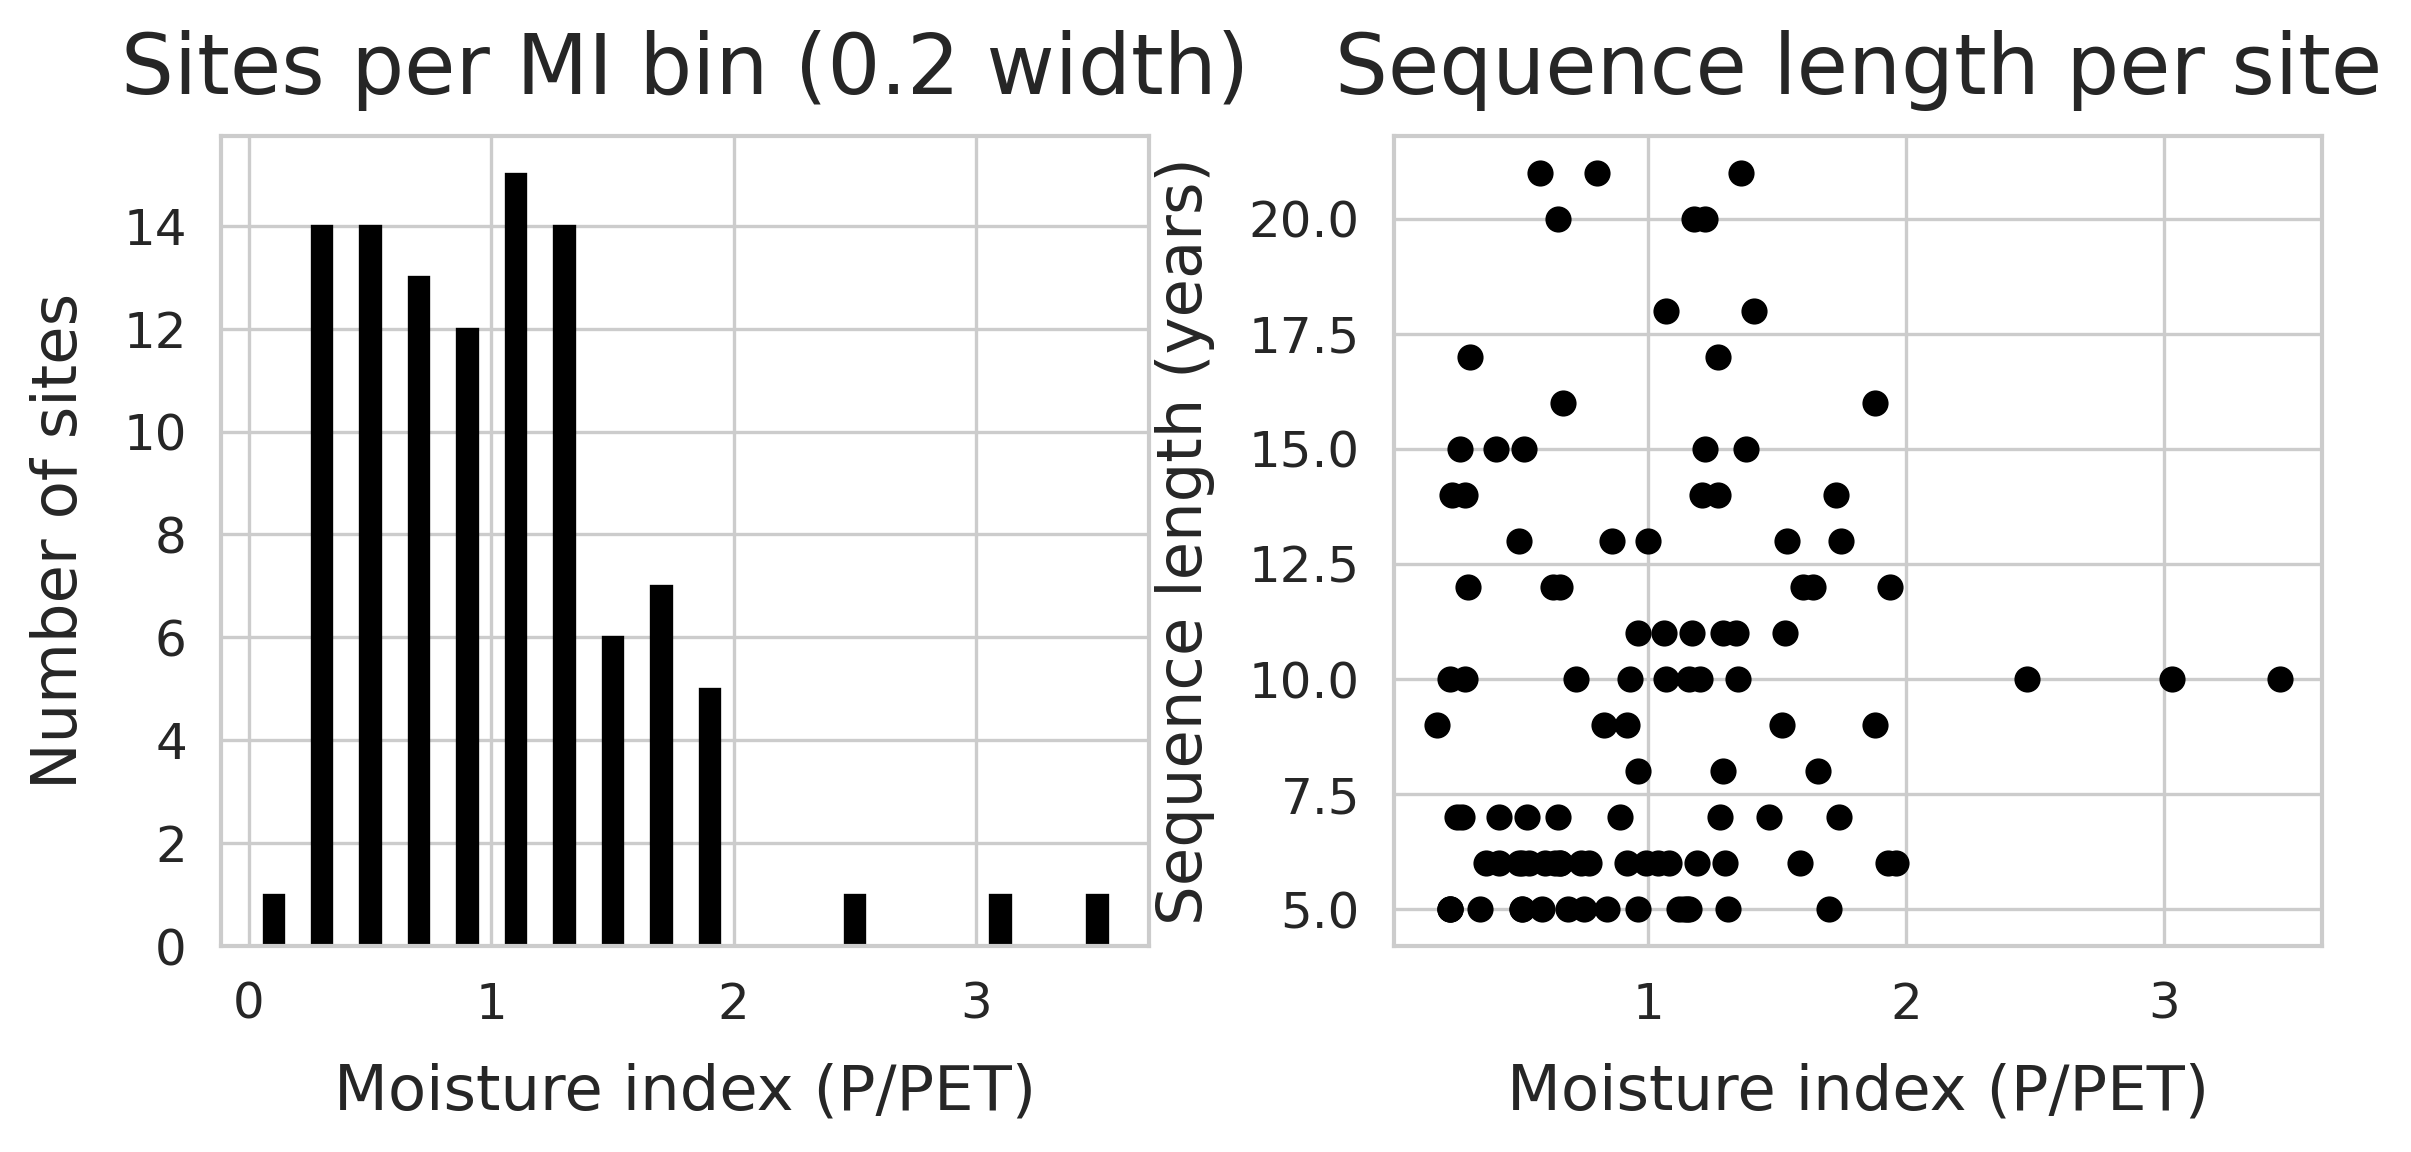

In [34]:
df_subset = site_metrics_df.copy()
df_subset['n_days'] = df.groupby('sitename').size().values
n_years = df_subset['n_days'] / 365

set_publication_style(figsize=(8,4))

mi_vals = df_subset["ai"].astype(float).dropna()
bins = np.arange(0, mi_vals.max() + 0.2, 0.2)
counts, edges = np.histogram(mi_vals, bins=bins)
bin_centers = 0.5 * (edges[:-1] + edges[1:])

mi_vals_len = df_subset["ai"].astype(float)
site_lengths = df_subset["n_days"].astype(float) / 365

fig, axes = plt.subplots(1, 2)

axes[0].bar(bin_centers, counts, width=0.08, color="black", edgecolor="black")
axes[0].set_xlabel("Moisture index (P/PET)")
axes[0].set_ylabel("Number of sites")
axes[0].set_title("Sites per MI bin (0.2 width)")

axes[1].scatter(mi_vals_len, site_lengths, color="black", s=30)
axes[1].set_xlabel("Moisture index (P/PET)")
axes[1].set_ylabel("Sequence length (years)")
axes[1].set_title("Sequence length per site")

plt.tight_layout()

# plt.savefig('figures/11_site_stats.png')

plt.show()

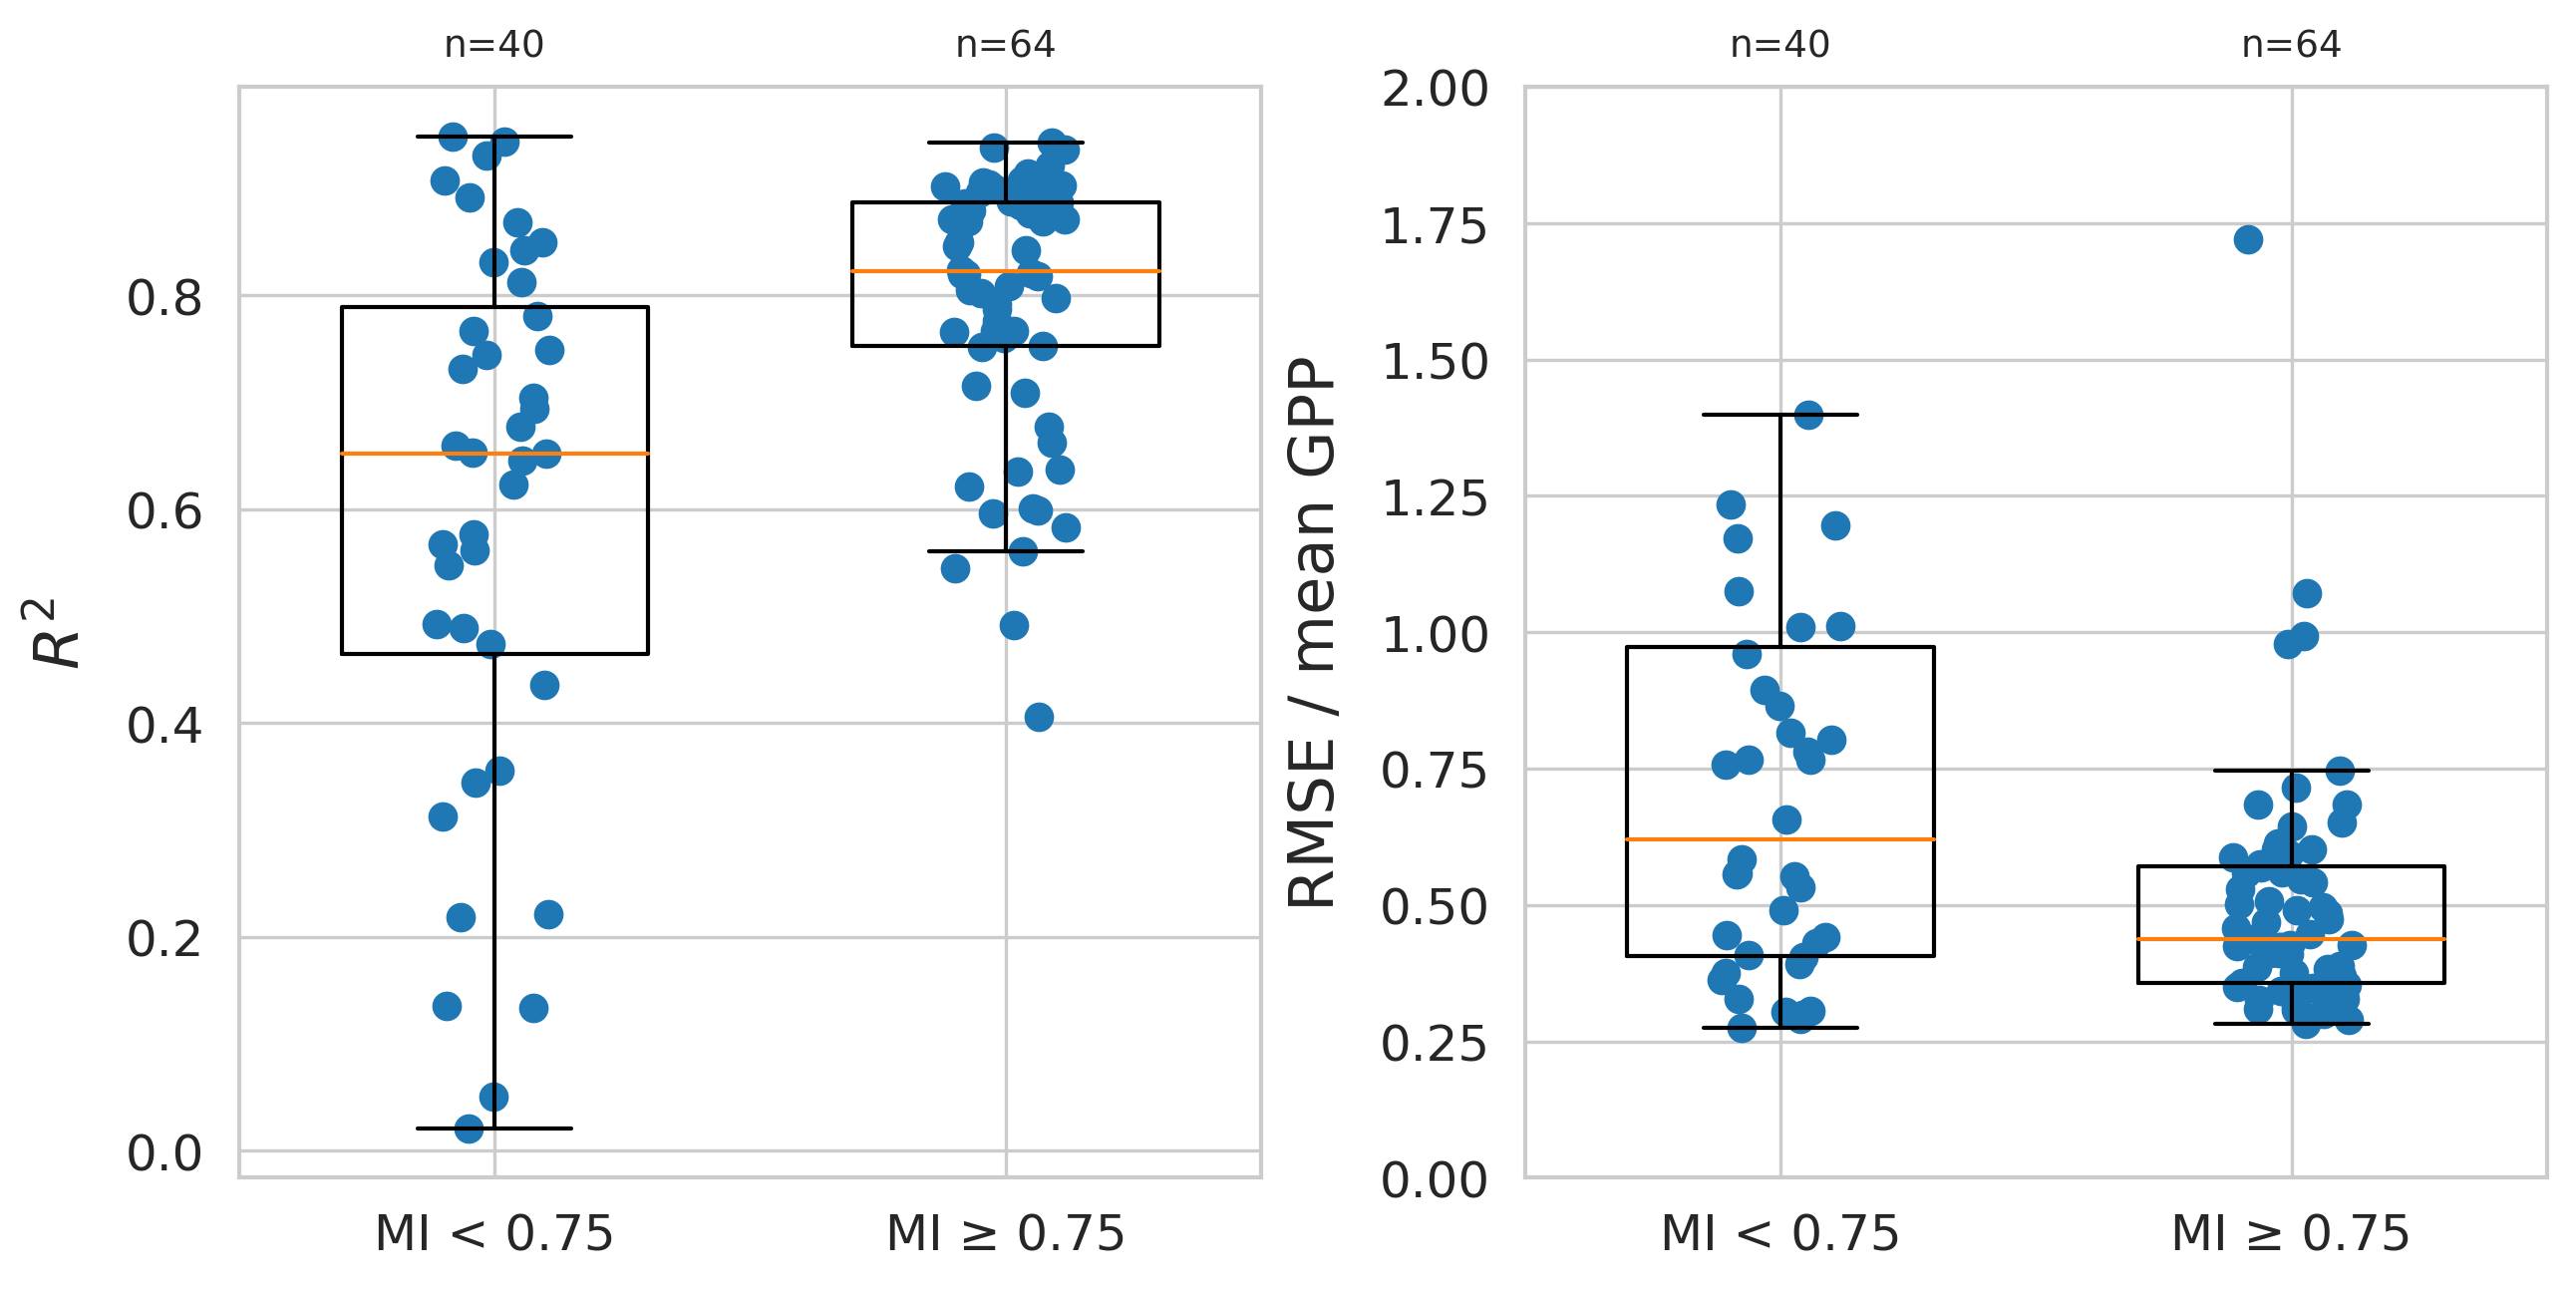

Medians:
MI < 0.75: 0.652
MI ≥ 0.75: 0.822
MI < 0.75: 0.620
MI ≥ 0.75: 0.437


In [35]:
import matplotlib.transforms as transforms

set_publication_style()
df_agg = site_metrics_df.copy()
df_agg["rmse_norm"] = df_agg["lstm_global_plus_rmse"] / df_agg["mean_gpp"]
groups = pd.Series(np.where(df_agg["ai"] >= 0.75, "MI ≥ 0.75", "MI < 0.75"))
labels = ["MI < 0.75", "MI ≥ 0.75"]
data_r2 = [df_agg.loc[groups == lab, "lstm_global_plus_r2"].dropna() for lab in labels]
data_rmse = [df_agg.loc[groups == lab, "rmse_norm"].dropna() for lab in labels]
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.2), constrained_layout=True)
for ax, data, ylabel in zip(axes, [data_r2, data_rmse], [r"$R^2$", "RMSE / mean GPP"]):
    x = np.arange(len(data))
    ax.boxplot(data, positions=x, widths=0.6, showfliers=False)
    for i, d in enumerate(data):
        if len(d) > 0:
            ax.scatter(np.full(len(d), i) + np.random.uniform(-0.12, 0.12, len(d)), d, s=40, color="C0")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
axes[1].set_ylim(0, 2)
def annotate_ns(ax, xs, ns, y_axes=1.02, fontsize=9):
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    for x, n in zip(xs, ns):
        ax.text(x, y_axes, f"n={n}", transform=trans, ha="center", va="bottom", fontsize=fontsize)
annotate_ns(axes[0], np.arange(len(data_r2)), [len(d) for d in data_r2])
annotate_ns(axes[1], np.arange(len(data_rmse)), [len(d) for d in data_rmse])

# plt.savefig('figures/12_agg.png')

plt.show()

print("Medians:")
for label, data in zip(labels, data_r2):
    median_val = np.median(data) if len(data) > 0 else float('nan')
    print(f"{label}: {median_val:.3f}")
for label, data in zip(labels, data_rmse):
    median_val = np.median(data) if len(data) > 0 else float('nan')
    print(f"{label}: {median_val:.3f}")



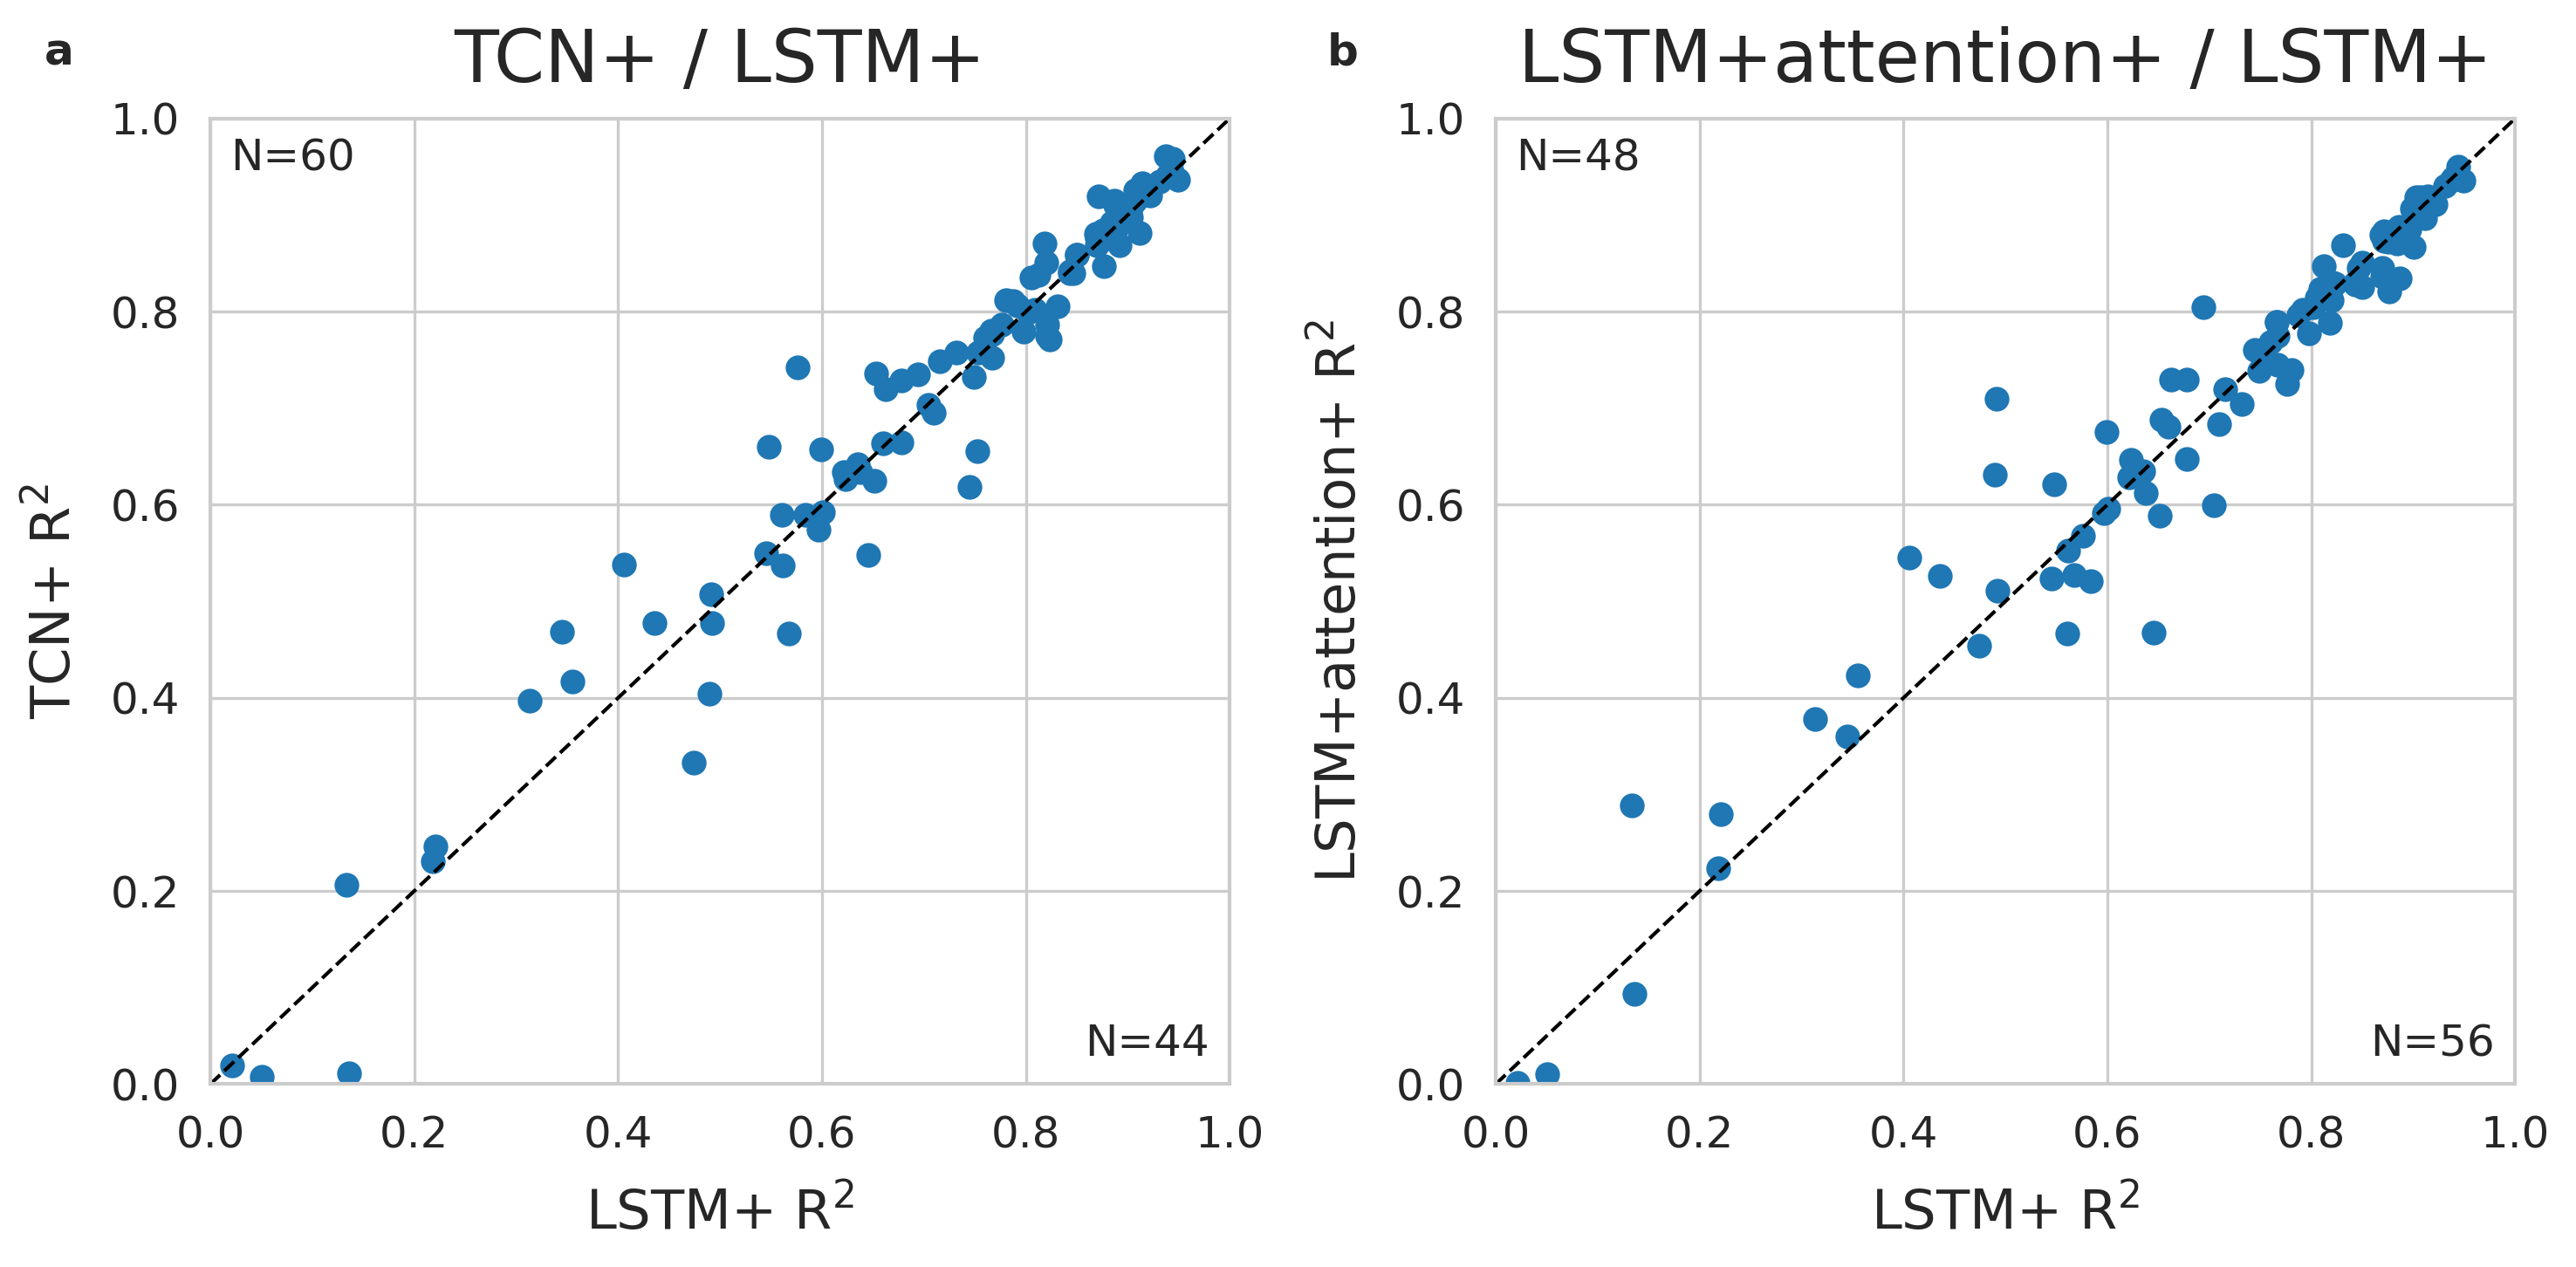

In [36]:
set_publication_style()
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

x = site_metrics_df['lstm_global_plus_r2']
y = site_metrics_df['tcn_global_plus_r2']
axes[0].scatter(x, y)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel(r'LSTM+ R$^2$')
axes[0].set_ylabel(r'TCN+ R$^2$')
axes[0].set_title('TCN+ / LSTM+')
n_lstm_better = (x > y).sum()
n_tcn_better = (y > x).sum()
axes[0].text(0.02, 0.98, f'N={n_tcn_better}', transform=axes[0].transAxes, ha='left', va='top')
axes[0].text(0.98, 0.02, f'N={n_lstm_better}', transform=axes[0].transAxes, ha='right', va='bottom')

x = site_metrics_df['lstm_global_plus_r2']
y = site_metrics_df['att_global_plus_r2']
axes[1].scatter(x, y)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel(r'LSTM+ R$^2$')
axes[1].set_ylabel(r'LSTM+attention+ R$^2$')
axes[1].set_title('LSTM+attention+ / LSTM+')
n_lstm_better = (x > y).sum()
n_att_better = (y > x).sum()
axes[1].text(0.02, 0.98, f'N={n_att_better}', transform=axes[1].transAxes, ha='left', va='top')
axes[1].text(0.98, 0.02, f'N={n_lstm_better}', transform=axes[1].transAxes, ha='right', va='bottom')

fig.text(0.025, 0.96, 'a', fontweight='heavy', fontfamily='sans-serif', ha='left', va='top')
fig.text(0.515, 0.96, 'b', fontweight='heavy', fontfamily='sans-serif', ha='left', va='top')

plt.tight_layout()

# plt.savefig('figures/13_alt_models.png')

plt.show()



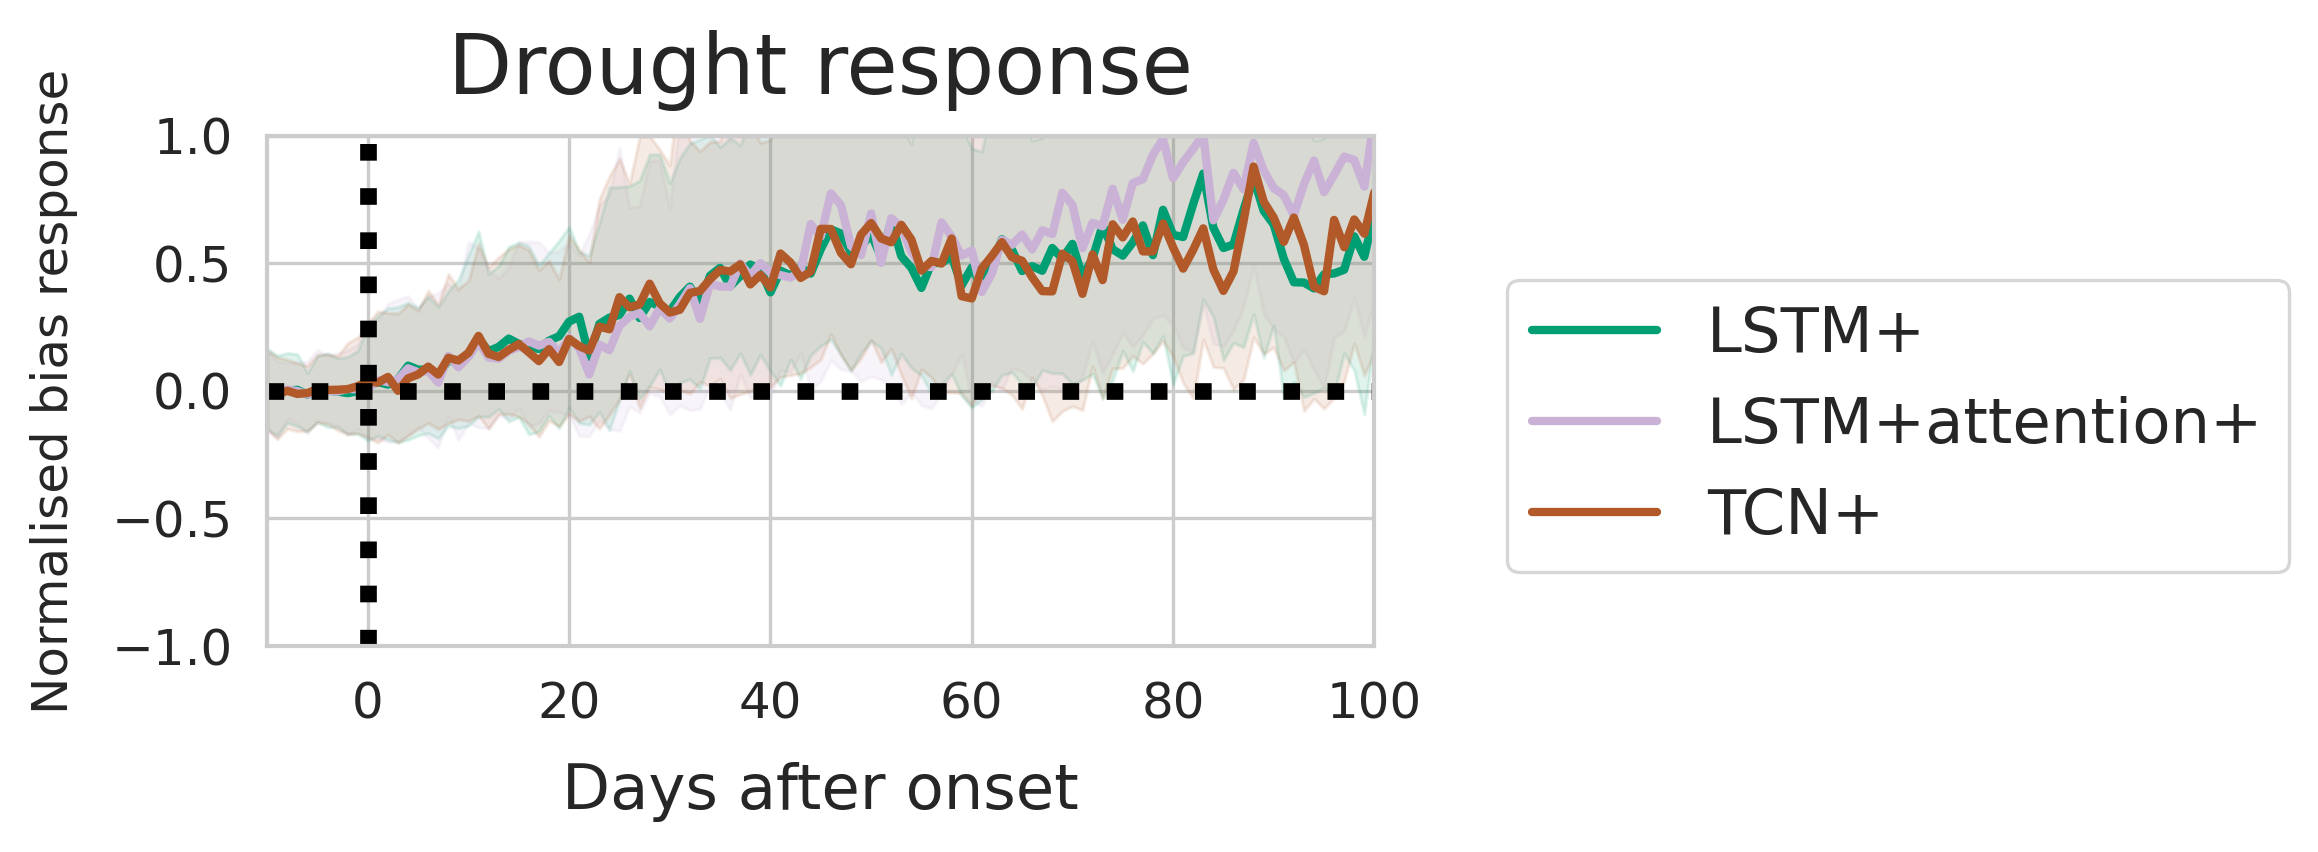

In [37]:
before = 10
after = 100
leng_threshold_drought = 3
nbins = 6
obs = "GPP_NT_VUT_REF"

outputs_drought = []
model_labels = []
model_cols = ['gpp_lstm_global_plus', 'gpp_att_global_plus', 'gpp_tcn_global_plus']

for model_key in model_cols:
    label = model_label_map[model_key]
    model_labels.append(label)
    outputs_drought.append(eval_eventresponse(
        df, df_drought_events,
        before=before, after=after,
        leng_threshold=leng_threshold_drought,
        nbins=nbins, do_norm=True,
        mod=model_key, obs=obs,
        cap_to_event=True
    ))

set_publication_style(figsize=(5,3))
fig, ax = plt.subplots(1, 1, figsize=(5,3), sharey=True)

xlim=(-10, 100)
ylim=(-1, 1)

# Drought panel
for lab, dct in zip(model_labels, outputs_drought):
    da = _agg_to_y(dct).sort_values("dday")
    color = colors[lab]
    if lab == 'Attn+':
        lab = 'LSTM+attention+'
    ax.fill_between(da["dday"], da["y_lo"], da["y_hi"], alpha=0.12, label=None, color=color)
    ax.plot(da["dday"], da["y_med"], lw=2, label=lab, color=color)
ax.axhline(0, ls=":", c="k"); ax.axvline(0, ls=":", c="k")
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_title("Drought response")
ax.set_xlabel("Days after onset")
ax.set_ylabel(r"Normalised bias response", fontsize=12)

# Legend to the right of the plot
handles, labels_leg = ax.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

# plt.savefig('figures/14_alt_models_events.png')